In [1]:
print("hello")

hello


In [2]:
# preprocessing.py
# Core preprocessing pipeline for
# UCI Online Retail II Dataset
# Complete preprocessing pipeline for UCI Online Retail II dataset.

import pandas as pd
import numpy as np


 # NON-PRODUCT / INTERNAL STOCK CODES
NON_PRODUCT_CODES = {"POST", "DOT", "BANK CHARGES", "AMAZONFEE", "MANUAL", "CRUK"}


 # MAIN PREPROCESSING FUNCTION
 
def preprocess_online_retail( file_path, verbose=True ): #accepting file path rn but will edit it later
    #Parameters: filepath, verbose: a bool weather to print the logs 
    #Returns: A single cleaned dataset

    #LOAD DATA 
    if verbose:
        print("\nLoading dataset...")

    df_orig = pd.read_excel(r"D:\online_retail\data\online_retail_II.xlsx", sheet_name=None)
    df = pd.concat(df_orig.values(), ignore_index=True)

    if verbose:
        print(f"Initial Shape: {df.shape}")


    # STANDARDIZE COLUMN NAMES 
    df.columns = (
        df.columns
          .str.strip()
          .str.replace(" ", "_")
    )


    # REMOVE MISSING CUSTOMER IDs
    missing_ids = df['Customer_ID'].isna().sum()

    if verbose:
        print(f"\nMissing Customer IDs: {missing_ids}")

    df = df.dropna(subset=['Customer_ID'])


    # FIX DATATYPES
    # Dates to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    # Customer ID to int then string to avoid floats
    df['Customer_ID'] = (
        df['Customer_ID']
          .astype(int)
          .astype(str)
    )
    # StockCode to a normalised str
    df['StockCode'] = (
        df['StockCode']
          .astype(str)
          .str.strip()
          .str.upper()
    )
    # Country
    df['Country'] = (
        df['Country']
          .astype(str)
          .str.strip()
          .str.title()
    )


    # REMOVE EXACT DUPLICATES  
    duplicate_count = df.duplicated().sum()
    if verbose:
        print(f"\nDuplicate Rows: {duplicate_count}")
    df = df.drop_duplicates()

      
    # REMOVE IMPOSSIBLE PRICES
    invalid_price_count = ((df['Price'] <= 0).sum())

    if verbose:
        print(f"\nRows with Invalid Prices: ", f"{invalid_price_count}")
    df = df[df['Price'] > 0]

    
    # REMOVE NON-PRODUCT STOCK CODES
    non_product_count = (df['StockCode'].isin(NON_PRODUCT_CODES).sum())
    if verbose:
        print(f"\nNon-product rows: ", f"{non_product_count}")
    # NOTE: We DO NOT remove them yet.
    # We preserve them in master dataset.
    # Downstream tasks can filter them.


    # CREATE FLAGS
    # Cancellation invoices
    df['IsCancelled'] = (
        df['Invoice']
          .astype(str)
          .str.startswith('C'))
    # Returns / negative quantities
    df['IsReturn'] = (df['Quantity'] <= 0)
    # Non-product / operational transactions
    df['IsNonProduct'] = (df['StockCode'].isin(NON_PRODUCT_CODES))

    
    # CREATE TRANSACTION VALUE
    df['TransactionValue'] = (df['Quantity'] * df['Price'])


    # SORT CHRONOLOGICALLY
    df = df.sort_values(by=['Customer_ID', 'InvoiceDate'])

    # RESET INDEX
    df = df.reset_index(drop=True)


    # FINAL LOGGING
    if verbose:

        print("\n========== FINAL SUMMARY ==========")

        print(f"\nFinal Dataset Shape: {df.shape}")

        print(f"\nUnique Customers: ", f"{df['Customer_ID'].nunique()}")

        print(f"Unique Invoices: ", f"{df['Invoice'].nunique()}")

        print(f"Date Range: ", f"{df['InvoiceDate'].min()} ", f"to ", f"{df['InvoiceDate'].max()}")

        print(f"\nCancelled Transactions: ", f"{df['IsCancelled'].sum()}")

        print(f"Return Transactions: ", f"{df['IsReturn'].sum()}")
        
        print("\n===================================")

    return df


In [3]:
df = preprocess_online_retail("D:\online_retail\data\online_retail_II.xlsx")
df.desc()

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\bhavi\AppData\Local\Temp\ipykernel_24936\1189884185.py:1: SyntaxWarning: invalid escape sequence '\o'
  df = preprocess_online_retail("D:\online_retail\data\online_retail_II.xlsx")



Loading dataset...
Initial Shape: (1067371, 8)

Missing Customer IDs: 243007

Duplicate Rows: 26479

Rows with Invalid Prices:  70

Non-product rows:  2052

========== FINAL SUMMARY ==========

Final Dataset Shape: (797815, 12)

Unique Customers:  5939
Unique Invoices:  44870
Date Range:  2009-12-01 07:45:00  to  2011-12-09 12:50:00

Cancelled Transactions:  18390
Return Transactions:  18390



AttributeError: 'DataFrame' object has no attribute 'desc'

o/p:
Loading dataset...
Initial Shape: (1067371, 8)

Missing Customer IDs: 243007

Duplicate Rows: 26479

Rows with Invalid Prices:  70

Non-product rows:  2052

========== FINAL SUMMARY ==========

Final Dataset Shape: (797815, 12)

Unique Customers:  5939
Unique Invoices:  44870
Date Range:  2009-12-01 07:45:00  to  2011-12-09 12:50:00

Cancelled Transactions:  18390
Return Transactions:  18390

===================================


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,IsCancelled,IsReturn,IsNonProduct,TransactionValue
0,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.5,12346,United Kingdom,False,False,False,45.0
1,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.5,12346,United Kingdom,False,False,False,22.5
2,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.5,12346,United Kingdom,False,False,False,22.5
3,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.5,12346,United Kingdom,False,False,False,22.5
4,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.0,12346,United Kingdom,False,False,False,1.0


In [5]:
df.describe()


,Quantity,InvoiceDate,Price,TransactionValue
count,797815.000000,797815,797815.000000,797815.000000
mean,12.585594,2011-01-02 13:15:39.345812992,3.703057,20.418256
min,-80995.000000,2009-12-01 07:45:00,0.001000,-168469.600000
25%,2.000000,2010-07-02 09:47:00,1.250000,4.350000
50%,5.000000,2010-12-02 12:33:00,1.950000,11.700000
75%,12.000000,2011-07-31 15:50:00,3.750000,19.500000
max,80995.000000,2011-12-09 12:50:00,38970.000000,168469.600000
std,191.163061,NaN,71.395672,313.532519


In [7]:
df.shape

(797815, 12)

In [16]:
df.loc[df['TransactionValue']<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,IsCancelled,IsReturn,IsNonProduct,TransactionValue
9,C495800,ADJUST,Adjustment by john on 26/01/2010 17,-1,2010-01-26 17:27:00,103.50,12346,United Kingdom,True,True,False,-103.50
34,C514024,M,Manual,-1,2010-06-30 11:22:00,5.18,12346,United Kingdom,True,True,False,-5.18
35,C514024,M,Manual,-1,2010-06-30 11:22:00,12.94,12346,United Kingdom,True,True,False,-12.94
36,C514024,M,Manual,-1,2010-06-30 11:22:00,4.66,12346,United Kingdom,True,True,False,-4.66
37,C514024,M,Manual,-1,2010-06-30 11:22:00,25.88,12346,United Kingdom,True,True,False,-25.88
...,...,...,...,...,...,...,...,...,...,...,...,...
797576,C525695,C2,CARRIAGE,-1,2010-10-06 12:31:00,25.00,18284,United Kingdom,True,True,False,-25.00
797606,C513486,79323G,GOLD CHERRY LIGHTS,-4,2010-06-24 17:51:00,6.75,18286,United Kingdom,True,True,False,-27.00
797607,C513486,79323S,SILVER CHERRY LIGHTS,-4,2010-06-24 17:51:00,6.75,18286,United Kingdom,True,True,False,-27.00
797608,C513486,79323B,BLACK CHERRY LIGHTS,-8,2010-06-24 17:51:00,6.75,18286,United Kingdom,True,True,False,-54.00


In [21]:
df.sort_values("InvoiceDate").head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,IsCancelled,IsReturn,IsNonProduct,TransactionValue
96583,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,False,100.8
96582,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,False,81.0
96581,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,False,81.0
96587,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,False,False,False,59.5
96586,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,False,30.0


In [22]:
df.sort_values("InvoiceDate").tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,IsCancelled,IsReturn,IsNonProduct,TransactionValue
39994,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,False,False,False,12.6
39995,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,False,False,False,16.6
39998,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680,France,False,False,True,18.0
39996,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,False,False,False,16.6
39984,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680,France,False,False,False,19.8


In [32]:
# classification_dataset.py

import pandas as pd
import numpy as np
 
# MAIN FUNCTION FOR BUILDING RETENTION CLASSIFICATION DATASET
def build_retention_dataset(df, cutoff_date='2011-09-09', prediction_days=90, active_days=180, verbose=True):

    # CONVERTING INPUT CUTOFF DATE INTO PANDAS TIMESTAMP
    # This becomes the boundary separating historical feature generation and Future clv label generation
    cutoff_date = pd.Timestamp(cutoff_date)

  
    # DEFINING FUTURE PREDICTION WINDOW END DATE
    # Customers purchasing between:
    # cutoff_date -> prediction_end
    # receive clv label = 1
    prediction_end = (cutoff_date + pd.Timedelta(days=prediction_days))

  
    # DEFINING RECENT ACTIVITY WINDOW
    # Customers inactive for too long before cutoff
    # are excluded to avoid trivial dead-user predictions
    active_start = (cutoff_date - pd.Timedelta(days=active_days))

  
    # FILTERING ONLY GENUINE PURCHASE TRANSACTIONS
    # Removing:
    # 1. Cancelled invoices
    # 2. Product returns
    # 3. Operational/non-product transactions
    purchase_df = df[
        (~df['IsCancelled']) &
        (~df['IsReturn']) &
        (~df['IsNonProduct'])].copy()

  
    # SORTING PURCHASES CHRONOLOGICALLY 
    # Sorting by customer then time is essential for:
    # 1. Gap calculations
    # 2. Recency features
    # 3. Temporal behavior modeling
    purchase_df = purchase_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # SPLITTING HISTORICAL AND FUTURE DATA
    # Historical data:
    # Used ONLY for feature engineering
    history_df = purchase_df[purchase_df['InvoiceDate'] < cutoff_date].copy()
    # Future data:
    # Used ONLY for retention label creation
    future_df = purchase_df[
        (purchase_df['InvoiceDate'] >= cutoff_date) &
        (purchase_df['InvoiceDate'] < prediction_end)
    ].copy()

  
    # IDENTIFYING RECENTLY ACTIVE CUSTOMERS
    # Keeping only customers active within recent window
    # avoids learning from ancient dormant customers
    recent_active_customers = (
        history_df[
            history_df['InvoiceDate'] >= active_start
        ]['Customer_ID']
        .unique()
    )

  
    # FILTERING HISTORY TO ACTIVE CUSTOMERS ONLY
    # This ensures:
    # every customer had at least some recent activity
    history_df = history_df[history_df['Customer_ID'].isin(recent_active_customers)]

  
    # FILTERING FUTURE DATA TO SAME CUSTOMER SET
    # Future labels must only exist for valid customers
    future_df = future_df[future_df['Customer_ID'].isin(recent_active_customers)]

  
    # CREATING INVOICE-LEVEL AGGREGATION
    # Raw dataset is transaction-line level:
    # one row per purchased item

    # Here we aggregate into one row per invoice/order
    # This captures cleaner order-level behavior
    invoice_df = (
        history_df
        .groupby(['Customer_ID', 'Invoice'])
        .agg({
            # First timestamp of invoice
            'InvoiceDate': 'min',
            # Total spend within invoice
            'TransactionValue': 'sum',
            # Total quantity purchased in invoice
            'Quantity': 'sum',
            # Number of unique products in invoice
            'StockCode': 'nunique'
        })
        .reset_index()
    )

  
    # SORTING INVOICE-LEVEL DATA CHRONOLOGICALLY
    # Required for temporal customer calculations
    invoice_df = invoice_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # CREATING CUSTOMER-LEVEL AGGREGATED FEATURES
    # Final dataset requires none row per customer
    # So invoice-level behavior is aggregated upward
    customer_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            # Most recent purchase timestamp
            LastPurchaseDate=('InvoiceDate', 'max'),
            # First ever purchase timestamp
            FirstPurchaseDate=('InvoiceDate', 'min'),
            # Total number of orders placed
            Frequency=('Invoice', 'nunique'),
            # Total customer spending
            Monetary=('TransactionValue', 'sum'),
            # Average spend per order
            AvgBasketValue=('TransactionValue', 'mean'),
            # Average quantity purchased per order
            AvgQuantity=('Quantity', 'mean'),
            # Total unique products purchased
            UniqueProducts=('StockCode', 'sum')
        )
        .reset_index()
    )

  
    # DERIVING RECENCY FEATURE
    # Measures: days since customer's last purchase
    # Lower recency usually means:
    # higher probability of returning
    customer_features['Recency'] = (cutoff_date - customer_features['LastPurchaseDate']).dt.days

  
    # DERIVING CUSTOMER LIFETIME FEATURE
    # Measures: duration between first and latest purchase
    # Helps distinguish new customers vs mature loyal customers
    customer_features['LifetimeDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days

  
    # PREVENTING DIVISION BY ZERO
    # Customers with single-day activity
    # would otherwise create divide-by-zero errors
    customer_features['LifetimeDays'] = (customer_features['LifetimeDays'].replace(0, 1))

    # FLAGGING RECENTLY ACQUIRED CUSTOMERS
    # New customers often behave differently from mature customers
    customer_features['IsNewCustomer'] = (
        customer_features['LifetimeDays'] <= 60
    ).astype(int)
  
    # DERIVING PURCHASE VELOCITY FEATURE
    # Measures: average order frequency per lifetime day
    # Captures long-term customer engagement intensity
    customer_features['PurchaseRate'] = (customer_features['Frequency']/customer_features['LifetimeDays'])

    # DERIVING REVENUE INTENSITY FEATURE
    # Measures average spending generated per day
    customer_features['RevenuePerDay'] = (
        customer_features['Monetary'] /
        customer_features['LifetimeDays']
    )

    # DERIVING PRODUCT SPEND INTENSITY FEATURE
    # Measures average spend per unique product purchased
    customer_features['AvgSpendPerProduct'] = (
        customer_features['Monetary'] /
        customer_features['UniqueProducts']
    )

    # DERIVING PRODUCT DIVERSITY FEATURE
    # Measures product variety purchased per order
    customer_features['ProductDiversityRate'] = (
        customer_features['UniqueProducts'] /
        customer_features['Frequency']
    )

    # CREATING PREVIOUS PURCHASE TIMESTAMPS
    # Previous invoice timestamps are needed
    # for inter-purchase gap calculations
    invoice_df['PrevInvoiceDate'] = (invoice_df.groupby('Customer_ID')['InvoiceDate'].shift(1))

  
    # CALCULATING INTER-PURCHASE GAPS
    # Measures: time gap between consecutive purchases
    # Highly informative behavioral feature
    invoice_df['GapDays'] = (invoice_df['InvoiceDate']-invoice_df['PrevInvoiceDate']).dt.days

  
    # DERIVING AVERAGE INTER-PURCHASE GAP
    # Customers with lower average gaps
    # often show stronger retention tendencies
    # DERIVING INTER-PURCHASE GAP STATISTICS
    gap_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            AvgGapDays=('GapDays', 'mean'),
            StdGapDays=('GapDays', 'std')
        )
        .reset_index()
    )

    # MERGING GAP FEATURES
    customer_features = customer_features.merge(
        gap_features,
        on='Customer_ID',
        how='left'
    )

    # SINGLE-PURCHASE CUSTOMERS HAVE NO GAP VARIANCE
    customer_features['StdGapDays'] = (
        customer_features['StdGapDays']
        .fillna(0)
    )

  
  
    # DEFINING RECENT 30-DAY ACTIVITY WINDOW
    # Recent activity often predicts
    # short-term retention strongly
    last_30_start = (cutoff_date - pd.Timedelta(days=30))

  
    # EXTRACTING RECENT CUSTOMER ACTIVITY
    # Captures customer momentum immediately
    # before prediction cutoff
    last_30_df = history_df[history_df['InvoiceDate'] >= last_30_start]

  
    # CREATING RECENT MOMENTUM FEATURES
    # These features capture:
    # recent engagement intensity
    recent_features = (
        last_30_df
        .groupby('Customer_ID')
        .agg(
            # Number of recent orders
            PurchasesLast30Days=('Invoice', 'nunique'),
            # Recent spending volume
            SpendLast30Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

  
    # MERGING RECENT MOMENTUM FEATURES
    customer_features = customer_features.merge(recent_features, on='Customer_ID', how='left')

  
    # FILLING MISSING RECENT ACTIVITY VALUES
    # Customers without recent purchases
    # should receive zeros instead of NaNs
    customer_features[['PurchasesLast30Days', 'SpendLast30Days']] = customer_features[['PurchasesLast30Days', 'SpendLast30Days']].fillna(0)

    
    # NEW
    # DEFINING RECENT 90-DAY ACTIVITY WINDOW
    # Captures medium-term customer engagement before cutoff
    last_90_start = (
        cutoff_date -
        pd.Timedelta(days=90)
    )


    # EXTRACTING LAST 90-DAY CUSTOMER ACTIVITY
    last_90_df = history_df[
        history_df['InvoiceDate'] >= last_90_start
    ]

    # CREATING MEDIUM-TERM MOMENTUM FEATURES
    recent_90_features = (
        last_90_df
        .groupby('Customer_ID')
        .agg(
            PurchasesLast90Days=('Invoice', 'nunique'),
            SpendLast90Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

    # MERGING MEDIUM-TERM MOMENTUM FEATURES
    customer_features = customer_features.merge(
        recent_90_features,
        on='Customer_ID',
        how='left'
    )

    # FILLING MISSING VALUES
    customer_features[
        ['PurchasesLast90Days', 'SpendLast90Days']
    ] = customer_features[
        ['PurchasesLast90Days', 'SpendLast90Days']
    ].fillna(0)



    # DEFINING PRIOR 90-DAY WINDOW
    # Window from cutoff-180 to cutoff-90
    prior_90_start = (
        cutoff_date -
        pd.Timedelta(days=180)
    )

    prior_90_end = (
        cutoff_date -
        pd.Timedelta(days=90)
    )

    # EXTRACTING PRIOR WINDOW ACTIVITY
    prior_90_df = history_df[
        (history_df['InvoiceDate'] >= prior_90_start) &
        (history_df['InvoiceDate'] < prior_90_end)
    ]

    # CALCULATING PRIOR WINDOW SPENDING
    prior_90_features = (
        prior_90_df
        .groupby('Customer_ID')
        .agg(
            SpendPrior90Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

    # MERGING PRIOR WINDOW FEATURES
    customer_features = customer_features.merge(
        prior_90_features,
        on='Customer_ID',
        how='left'
    )

    # FILLING MISSING VALUES
    customer_features[
        'SpendPrior90Days'
    ] = customer_features[
        'SpendPrior90Days'
    ].fillna(0)



    # DERIVING SPENDING MOMENTUM FEATURE
    # Ratio > 1 means accelerating spend
    # Ratio < 1 means declining spend
    customer_features['SpendTrendRatio'] = (
        customer_features['SpendLast90Days'] /
        (
            customer_features['SpendPrior90Days']
            + 1
        )
    )


    # COLLECTING HISTORICAL RETURN/CANCELLATION DATA
    # Behavioral instability signals
    # may help predict retention
    cancellation_df = df[(df['InvoiceDate'] < cutoff_date)]

  
    # CREATING RETURN/CANCELLATION FEATURES
    cancellation_features = (
        cancellation_df
        .groupby('Customer_ID')
        .agg(
            # Total historical transaction count
            TotalTransactions=('Invoice', 'count'),
            # Number of cancelled transactions
            CancelledTransactions=('IsCancelled', 'sum'),
            # Number of returned transactions
            ReturnedTransactions=('IsReturn', 'sum')
        ).reset_index())

  
    # DERIVING CANCELLATION RATE
    # Measures: proportion of customer cancellations
    cancellation_features['CancellationRate'] = (cancellation_features['CancelledTransactions']/cancellation_features['TotalTransactions'])

  
    # DERIVING RETURN RATE
    # Measures: proportion of customer returns
    cancellation_features['ReturnRate'] = (cancellation_features['ReturnedTransactions']/cancellation_features['TotalTransactions'])

  
    # MERGING CANCELLATION FEATURES
    customer_features = customer_features.merge(cancellation_features[
            [
                'Customer_ID',
                'CancellationRate',
                'ReturnRate'
            ]
        ],
        on='Customer_ID',
        how='left')

  
    # IDENTIFYING FUTURE RETURNING CUSTOMERS
    # Customers purchasing during future window
    # become positive retention examples
    future_labels = (
        future_df
        .groupby('Customer_ID')['Invoice']
        .nunique()
        .reset_index()
    )

  
    # ASSIGNING POSITIVE RETENTION LABELS
    future_labels['RetentionLabel'] = 1

  
    # MERGING LABELS INTO FINAL FEATURE TABLE
    customer_features = customer_features.merge(
        future_labels[
            ['Customer_ID', 'RetentionLabel']
        ],
        on='Customer_ID',
        how='left'
    )

  
    # ASSIGNING NEGATIVE LABELS TO NON-RETURNERS
    # Customers absent in future purchases
    # are labeled as non-retained
    customer_features['RetentionLabel'] = (
        customer_features['RetentionLabel']
        .fillna(0)
        .astype(int)
    )

  
    # REMOVING RAW TIMESTAMP COLUMNS
    # Derived features already contain needed information
    customer_features = customer_features.drop(columns=['LastPurchaseDate','FirstPurchaseDate'])

  
    # PRINTING FINAL DATASET STATISTICS
    if verbose:

        print(f"Cutoff date: {cutoff_date.date()}")

        print(f"Prediction end: {prediction_end.date()}")

        print(f"Active customer window: {active_days} days")

        print(f"Final dataset shape: {customer_features.shape}")

        print(f"Customers retained: ", f"{customer_features['RetentionLabel'].mean():.2%}")

        print(f"Positive labels: ", f"{customer_features['RetentionLabel'].sum()}")

        print(f"Negative labels: ", f"{(customer_features['RetentionLabel'] == 0).sum()}")

    return customer_features


 
# TEST EXECUTION
 

if __name__ == "__main__":

    # Importing preprocessing pipeline
    from preprocessing import preprocess_online_retail

    # Loading cleaned master transaction dataset
    df = preprocess_online_retail(
        file_path="online_retail_II.xlsx",
        verbose=False
    )

    # Building customer-level retention dataset
    retention_df = build_retention_dataset(
        df,
        cutoff_date='2011-09-09',
        prediction_days=90,
        active_days=180,
        verbose=True
    )

    # Printing sample rows from final dataset
    retention_df.head()

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 24)
Customers retained:  61.45%
Positive labels:  1707
Negative labels:  1071


In [33]:
retention_df.head()

,Customer_ID,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,IsNewCustomer,PurchaseRate,...,StdGapDays,PurchasesLast30Days,SpendLast30Days,PurchasesLast90Days,SpendLast90Days,SpendPrior90Days,SpendTrendRatio,CancellationRate,ReturnRate,RetentionLabel
0,12347,6,3402.39,567.065000,349.833333,164,37,274,0,0.021898,...,12.759310,0.0,0.0,1.0,584.91,1018.77,0.573571,0.000000,0.000000,1
1,12348,4,1388.40,347.100000,622.000000,40,156,189,0,0.021164,...,21.377558,0.0,0.0,0.0,0.00,327.00,0.000000,0.000000,0.000000,1
2,12352,7,1825.61,260.801429,62.857143,52,170,130,0,0.053846,...,28.891175,0.0,0.0,0.0,0.00,240.66,0.000000,0.151515,0.151515,1
3,12353,2,406.76,203.380000,106.000000,24,112,204,0,0.009804,...,0.000000,0.0,0.0,0.0,0.00,89.00,0.000000,0.000000,0.000000,0
4,12354,1,1079.40,1079.400000,530.000000,58,140,1,1,1.000000,...,0.000000,0.0,0.0,0.0,0.00,1079.40,0.000000,0.000000,0.000000,0


In [26]:
retention_df.loc[retention_df["Recency"]<15]

,Customer_ID,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,PurchaseRate,AvgGapDays,PurchasesLast30Days,SpendLast30Days,CancellationRate,ReturnRate,RetentionLabel
14,12375,1,190.30,190.300000,86.000000,10,6,1,1.000000,NaN,1.0,190.30,0.000000,0.000000,1
30,12408,7,3226.27,460.895714,262.857143,130,6,399,0.017544,66.166667,1.0,582.28,0.068493,0.068493,1
35,12415,21,121281.72,5775.320000,3846.333333,811,7,428,0.049065,20.950000,3.0,24822.16,0.068807,0.068807,1
36,12417,18,5255.83,291.990556,139.888889,308,14,626,0.028754,36.411765,1.0,517.69,0.026946,0.026946,1
39,12422,14,4697.80,335.557143,184.357143,164,3,625,0.022400,47.538462,1.0,147.70,0.022727,0.022727,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2751,18230,7,3627.22,518.174286,244.285714,123,2,431,0.016241,71.333333,1.0,503.08,0.016000,0.016000,1
2758,18241,15,2263.48,150.898667,76.000000,129,7,518,0.028958,36.642857,5.0,431.50,0.015267,0.015267,1
2766,18261,1,224.80,224.800000,102.000000,15,3,1,1.000000,NaN,1.0,224.80,0.000000,0.000000,1
2773,18273,3,306.00,102.000000,40.000000,3,3,494,0.006073,247.000000,1.0,102.00,0.000000,0.000000,1


In [34]:
retention_df.value_counts("CancellationRate")

CancellationRate
0.000000    1299
0.111111      12
0.083333      11
0.035714       9
0.062500       9
            ... 
0.457944       1
0.466667       1
0.006711       1
0.647059       1
0.002096       1
Name: count, Length: 926, dtype: int64

In [35]:
retention_df.value_counts("ReturnRate")

ReturnRate
0.000000    1299
0.111111      12
0.083333      11
0.035714       9
0.062500       9
            ... 
0.457944       1
0.466667       1
0.006711       1
0.647059       1
0.002096       1
Name: count, Length: 926, dtype: int64

In [29]:
retention_df.value_counts("Customer_ID")

Customer_ID
12347    1
12348    1
12352    1
12353    1
12354    1
        ..
18273    1
18281    1
18282    1
18283    1
18287    1
Name: count, Length: 2778, dtype: int64

In [40]:
retention_df[
    ['CancellationRate','ReturnRate']
].corr()

,CancellationRate,ReturnRate
CancellationRate,1.0,1.0
ReturnRate,1.0,1.0


In [42]:
corr = retention_df.drop(
    columns=['Customer_ID']
).corr()

target_corr = (
    corr['RetentionLabel']
    .sort_values(ascending=False)
)

print(target_corr)

RetentionLabel          1.000000
PurchasesLast90Days     0.236231
Frequency               0.232417
LifetimeDays            0.232107
UniqueProducts          0.204935
PurchasesLast30Days     0.203107
Monetary                0.123779
SpendLast90Days         0.122561
SpendLast30Days         0.106317
SpendPrior90Days        0.105958
ProductDiversityRate    0.095831
AvgQuantity             0.058896
AvgBasketValue          0.036633
SpendTrendRatio        -0.007599
CancellationRate       -0.013203
ReturnRate             -0.013203
AvgSpendPerProduct     -0.031290
RevenuePerDay          -0.052801
StdGapDays             -0.063511
PurchaseRate           -0.207020
IsNewCustomer          -0.209974
Recency                -0.271378
AvgGapDays             -0.315575
Name: RetentionLabel, dtype: float64


In [38]:
retention_df.nunique().sort_values()

IsNewCustomer              2
RetentionLabel             2
PurchasesLast30Days       12
PurchasesLast90Days       24
Frequency                 80
Recency                  148
UniqueProducts           591
LifetimeDays             608
SpendLast30Days          921
CancellationRate         926
ReturnRate               926
ProductDiversityRate    1164
AvgGapDays              1567
PurchaseRate            1612
SpendLast90Days         1870
SpendTrendRatio         1883
StdGapDays              1898
SpendPrior90Days        1958
AvgQuantity             2054
Monetary                2760
AvgBasketValue          2763
AvgSpendPerProduct      2771
RevenuePerDay           2771
Customer_ID             2778
dtype: int64

In [43]:
retention_df.groupby(
    'RetentionLabel'
)['RevenuePerDay'].mean()

RetentionLabel
0    133.959516
1     46.985417
Name: RevenuePerDay, dtype: float64

In [44]:
retention_df = retention_df.drop(
    columns=['CancellationRate']
)

In [45]:
# updated classification_dataset.py

import pandas as pd
import numpy as np
 
# MAIN FUNCTION FOR BUILDING RETENTION CLASSIFICATION DATASET
def build_retention_dataset(df, cutoff_date='2011-09-09', prediction_days=90, active_days=180, verbose=True):

    # CONVERTING INPUT CUTOFF DATE INTO PANDAS TIMESTAMP
    # This becomes the boundary separating historical feature generation and Future retention label generation
    cutoff_date = pd.Timestamp(cutoff_date)

  
    # DEFINING FUTURE PREDICTION WINDOW END DATE
    # Customers purchasing between:
    # cutoff_date -> prediction_end
    # receive retention label = 1
    prediction_end = (cutoff_date + pd.Timedelta(days=prediction_days))

  
    # DEFINING RECENT ACTIVITY WINDOW
    # Customers inactive for too long before cutoff
    # are excluded to avoid trivial dead-user predictions
    active_start = (cutoff_date - pd.Timedelta(days=active_days))

  
    # FILTERING ONLY GENUINE PURCHASE TRANSACTIONS
    # Removing:
    # 1. Cancelled invoices
    # 2. Product returns
    # 3. Operational/non-product transactions
    purchase_df = df[
        (~df['IsCancelled']) &
        (~df['IsReturn']) &
        (~df['IsNonProduct'])].copy()

  
    # SORTING PURCHASES CHRONOLOGICALLY 
    # Sorting by customer then time is essential for:
    # 1. Gap calculations
    # 2. Recency features
    # 3. Temporal behavior modeling
    purchase_df = purchase_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # SPLITTING HISTORICAL AND FUTURE DATA
    # Historical data:
    # Used ONLY for feature engineering
    history_df = purchase_df[purchase_df['InvoiceDate'] < cutoff_date].copy()
    # Future data:
    # Used ONLY for retention label creation
    future_df = purchase_df[
        (purchase_df['InvoiceDate'] >= cutoff_date) &
        (purchase_df['InvoiceDate'] < prediction_end)
    ].copy()

  
    # IDENTIFYING RECENTLY ACTIVE CUSTOMERS
    # Keeping only customers active within recent window
    # avoids learning from ancient dormant customers
    recent_active_customers = (
        history_df[
            history_df['InvoiceDate'] >= active_start
        ]['Customer_ID']
        .unique()
    )

  
    # FILTERING HISTORY TO ACTIVE CUSTOMERS ONLY
    # This ensures:
    # every customer had at least some recent activity
    history_df = history_df[history_df['Customer_ID'].isin(recent_active_customers)]

  
    # FILTERING FUTURE DATA TO SAME CUSTOMER SET
    # Future labels must only exist for valid customers
    future_df = future_df[future_df['Customer_ID'].isin(recent_active_customers)]

  
    # CREATING INVOICE-LEVEL AGGREGATION
    # Raw dataset is transaction-line level:
    # one row per purchased item

    # Here we aggregate into one row per invoice/order
    # This captures cleaner order-level behavior
    invoice_df = (
        history_df
        .groupby(['Customer_ID', 'Invoice'])
        .agg({
            # First timestamp of invoice
            'InvoiceDate': 'min',
            # Total spend within invoice
            'TransactionValue': 'sum',
            # Total quantity purchased in invoice
            'Quantity': 'sum',
            # Number of unique products in invoice
            'StockCode': 'nunique'
        })
        .reset_index()
    )

  
    # SORTING INVOICE-LEVEL DATA CHRONOLOGICALLY
    # Required for temporal customer calculations
    invoice_df = invoice_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # CREATING CUSTOMER-LEVEL AGGREGATED FEATURES
    # Final dataset requires none row per customer
    # So invoice-level behavior is aggregated upward
    customer_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            # Most recent purchase timestamp
            LastPurchaseDate=('InvoiceDate', 'max'),
            # First ever purchase timestamp
            FirstPurchaseDate=('InvoiceDate', 'min'),
            # Total number of orders placed
            Frequency=('Invoice', 'nunique'),
            # Total customer spending
            Monetary=('TransactionValue', 'sum'),
            # Average spend per order
            AvgBasketValue=('TransactionValue', 'mean'),
            # Average quantity purchased per order
            AvgQuantity=('Quantity', 'mean'),
            # Total unique products purchased
            UniqueProducts=('StockCode', 'sum')
        )
        .reset_index()
    )

  
    # DERIVING RECENCY FEATURE
    # Measures: days since customer's last purchase
    # Lower recency usually means:
    # higher probability of returning
    customer_features['Recency'] = (cutoff_date - customer_features['LastPurchaseDate']).dt.days

  
    # DERIVING CUSTOMER LIFETIME FEATURE
    # Measures: duration between first and latest purchase
    # Helps distinguish new customers vs mature loyal customers
    customer_features['LifetimeDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days

  
    # PREVENTING DIVISION BY ZERO
    # Customers with single-day activity
    # would otherwise create divide-by-zero errors
    customer_features['LifetimeDays'] = (customer_features['LifetimeDays'].replace(0, 1))

    # FLAGGING RECENTLY ACQUIRED CUSTOMERS
    # New customers often behave differently from mature customers
    customer_features['IsNewCustomer'] = (
        customer_features['LifetimeDays'] <= 60
    ).astype(int)
  
    # DERIVING PURCHASE VELOCITY FEATURE
    # Measures: average order frequency per lifetime day
    # Captures long-term customer engagement intensity
    customer_features['PurchaseRate'] = (customer_features['Frequency']/customer_features['LifetimeDays'])

    # DERIVING RECENCY-FREQUENCY INTERACTION
    # Combines freshness and loyalty into one signal
    customer_features['RecencyFrequency'] = (customer_features['Recency'] / customer_features['Frequency'])

    # DERIVING REVENUE INTENSITY FEATURE
    # Measures average spending generated per day
    customer_features['RevenuePerDay'] = (
        customer_features['Monetary'] /
        customer_features['LifetimeDays']
    )

    # DERIVING PRODUCT SPEND INTENSITY FEATURE
    # Measures average spend per unique product purchased
    customer_features['AvgSpendPerProduct'] = (
        customer_features['Monetary'] /
        customer_features['UniqueProducts']
    )

    # DERIVING PRODUCT DIVERSITY FEATURE
    # Measures product variety purchased per order
    customer_features['ProductDiversityRate'] = (
        customer_features['UniqueProducts'] /
        customer_features['Frequency']
    )

    # CREATING PREVIOUS PURCHASE TIMESTAMPS
    # Previous invoice timestamps are needed
    # for inter-purchase gap calculations
    invoice_df['PrevInvoiceDate'] = (invoice_df.groupby('Customer_ID')['InvoiceDate'].shift(1))

  
    # CALCULATING INTER-PURCHASE GAPS
    # Measures: time gap between consecutive purchases
    # Highly informative behavioral feature
    invoice_df['GapDays'] = (invoice_df['InvoiceDate']-invoice_df['PrevInvoiceDate']).dt.days

  
    # DERIVING AVERAGE INTER-PURCHASE GAP
    # Customers with lower average gaps
    # often show stronger retention tendencies
    # DERIVING INTER-PURCHASE GAP STATISTICS
    gap_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            AvgGapDays=('GapDays', 'mean'),
            StdGapDays=('GapDays', 'std')
        )
        .reset_index()
    )


    # MERGING GAP FEATURES
    customer_features = customer_features.merge(
        gap_features,
        on='Customer_ID',
        how='left'
    )


    # SINGLE-PURCHASE CUSTOMERS HAVE NO GAP VARIANCE
    customer_features['StdGapDays'] = (
        customer_features['StdGapDays']
        .fillna(0)
    )


  
    # DEFINING RECENT 30-DAY ACTIVITY WINDOW
    # Recent activity often predicts
    # short-term retention strongly
    last_30_start = (cutoff_date - pd.Timedelta(days=30))

  
    # EXTRACTING RECENT CUSTOMER ACTIVITY
    # Captures customer momentum immediately
    # before prediction cutoff
    last_30_df = history_df[history_df['InvoiceDate'] >= last_30_start]

  
    # CREATING RECENT MOMENTUM FEATURES
    # These features capture:
    # recent engagement intensity
    recent_features = (
        last_30_df
        .groupby('Customer_ID')
        .agg(
            # Number of recent orders
            PurchasesLast30Days=('Invoice', 'nunique'),
            # Recent spending volume
            SpendLast30Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

  
    # MERGING RECENT MOMENTUM FEATURES
    customer_features = customer_features.merge(recent_features, on='Customer_ID', how='left')

  
    # FILLING MISSING RECENT ACTIVITY VALUES
    # Customers without recent purchases
    # should receive zeros instead of NaNs
    customer_features[['PurchasesLast30Days', 'SpendLast30Days']] = customer_features[['PurchasesLast30Days', 'SpendLast30Days']].fillna(0)



    # NEW
    # DEFINING RECENT 90-DAY ACTIVITY WINDOW
    # Captures medium-term customer engagement before cutoff
    last_90_start = (
        cutoff_date -
        pd.Timedelta(days=90)
    )


    # EXTRACTING LAST 90-DAY CUSTOMER ACTIVITY
    last_90_df = history_df[
        history_df['InvoiceDate'] >= last_90_start
    ]

    # CREATING MEDIUM-TERM MOMENTUM FEATURES
    recent_90_features = (
        last_90_df
        .groupby('Customer_ID')
        .agg(
            PurchasesLast90Days=('Invoice', 'nunique'),
            SpendLast90Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

    # MERGING MEDIUM-TERM MOMENTUM FEATURES
    customer_features = customer_features.merge(
        recent_90_features,
        on='Customer_ID',
        how='left'
    )

    # FILLING MISSING VALUES
    customer_features[
        ['PurchasesLast90Days', 'SpendLast90Days']
    ] = customer_features[
        ['PurchasesLast90Days', 'SpendLast90Days']
    ].fillna(0)



    # DEFINING PRIOR 90-DAY WINDOW
    # Window from cutoff-180 to cutoff-90
    prior_90_start = (
        cutoff_date -
        pd.Timedelta(days=180)
    )

    prior_90_end = (
        cutoff_date -
        pd.Timedelta(days=90)
    )

    # EXTRACTING PRIOR WINDOW ACTIVITY
    prior_90_df = history_df[
        (history_df['InvoiceDate'] >= prior_90_start) &
        (history_df['InvoiceDate'] < prior_90_end)
    ]

    # CALCULATING PRIOR WINDOW ACTIVITY
    prior_90_features = (
        prior_90_df
        .groupby('Customer_ID')
        .agg(
            SpendPrior90Days=('TransactionValue', 'sum'),
            PurchasesPrior90Days=('Invoice', 'nunique')
        )
        .reset_index()
    )

    # MERGING PRIOR WINDOW FEATURES
    customer_features = customer_features.merge(
        prior_90_features,
        on='Customer_ID',
        how='left'
    )

    customer_features[
        ['SpendPrior90Days','PurchasesPrior90Days']
    ] = customer_features[
        ['SpendPrior90Days','PurchasesPrior90Days']
    ].fillna(0)



    # DERIVING SPENDING MOMENTUM FEATURE
    # Ratio > 1 means accelerating spend
    # Ratio < 1 means declining spend
    customer_features['SpendTrendRatio'] = (
        customer_features['SpendLast90Days'] /
        (
            customer_features['SpendPrior90Days']
            + 1
        )
    )


    # DERIVING PURCHASE MOMENTUM FEATURE
    # Ratio > 1 means increasing purchase frequency
    # Ratio < 1 means declining purchase frequency
    customer_features['FrequencyLast90DaysRatio'] = (
        customer_features['PurchasesLast90Days'] /
        (
            customer_features['PurchasesPrior90Days']
            + 1
        )
    )


    # COLLECTING HISTORICAL RETURN/CANCELLATION DATA
    # Behavioral instability signals
    # may help predict retention
    cancellation_df = df[(df['InvoiceDate'] < cutoff_date)]

  
    # CREATING RETURN/CANCELLATION FEATURES
    cancellation_features = (
        cancellation_df
        .groupby('Customer_ID')
        .agg(
            # Total historical transaction count
            TotalTransactions=('Invoice', 'count'),
            # Number of cancelled transactions
            CancelledTransactions=('IsCancelled', 'sum'),
            # Number of returned transactions
            ReturnedTransactions=('IsReturn', 'sum')
        ).reset_index())

  
    '''# DERIVING CANCELLATION RATE
    # Measures: proportion of customer cancellations
    cancellation_features['CancellationRate'] = (cancellation_features['CancelledTransactions']/cancellation_features['TotalTransactions'])
    '''
  
    # DERIVING RETURN RATE
    # Measures: proportion of customer returns
    # Found out that cancellation rate and return rate are same, correlation = 1.0
    cancellation_features['ReturnRate'] = (cancellation_features['ReturnedTransactions']/cancellation_features['TotalTransactions'])

  
    # MERGING CANCELLATION FEATURES
    customer_features = customer_features.merge(cancellation_features[
            [
                'Customer_ID',
                'ReturnRate'
            ]
        ],
        on='Customer_ID',
        how='left')

  
    # IDENTIFYING FUTURE RETURNING CUSTOMERS
    # Customers purchasing during future window
    # become positive retention examples
    future_labels = (
        future_df
        .groupby('Customer_ID')['Invoice']
        .nunique()
        .reset_index()
    )

  
    # ASSIGNING POSITIVE RETENTION LABELS
    future_labels['RetentionLabel'] = 1

  
    # MERGING LABELS INTO FINAL FEATURE TABLE
    customer_features = customer_features.merge(
        future_labels[
            ['Customer_ID', 'RetentionLabel']
        ],
        on='Customer_ID',
        how='left'
    )

  
    # ASSIGNING NEGATIVE LABELS TO NON-RETURNERS
    # Customers absent in future purchases
    # are labeled as non-retained
    customer_features['RetentionLabel'] = (
        customer_features['RetentionLabel']
        .fillna(0)
        .astype(int)
    )

  
    # REMOVING RAW TIMESTAMP COLUMNS
    # Derived features already contain needed information
    customer_features = customer_features.drop(columns=['LastPurchaseDate','FirstPurchaseDate'])

  
    # PRINTING FINAL DATASET STATISTICS
    if verbose:

        print(f"Cutoff date: {cutoff_date.date()}")

        print(f"Prediction end: {prediction_end.date()}")

        print(f"Active customer window: {active_days} days")

        print(f"Final dataset shape: {customer_features.shape}")

        print(f"Customers retained: ", f"{customer_features['RetentionLabel'].mean():.2%}")

        print(f"Positive labels: ", f"{customer_features['RetentionLabel'].sum()}")

        print(f"Negative labels: ", f"{(customer_features['RetentionLabel'] == 0).sum()}")

    return customer_features


 
# TEST EXECUTION
 

if __name__ == "__main__":

    # Importing preprocessing pipeline
    from preprocessing import preprocess_online_retail

    # Loading cleaned master transaction dataset
    df = preprocess_online_retail(
        file_path="online_retail_II.xlsx",
        verbose=False
    )

    # Building customer-level retention dataset
    retention_df = build_retention_dataset(
        df,
        cutoff_date='2011-09-09',
        prediction_days=90,
        active_days=180,
        verbose=True
    )

    # Printing sample rows from final dataset
    print(retention_df.head())

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers retained:  61.45%
Positive labels:  1707
Negative labels:  1071
  Customer_ID  Frequency  Monetary  AvgBasketValue  AvgQuantity  \
0       12347          6   3402.39      567.065000   349.833333   
1       12348          4   1388.40      347.100000   622.000000   
2       12352          7   1825.61      260.801429    62.857143   
3       12353          2    406.76      203.380000   106.000000   
4       12354          1   1079.40     1079.400000   530.000000   

   UniqueProducts  Recency  LifetimeDays  IsNewCustomer  PurchaseRate  ...  \
0             164       37           274              0      0.021898  ...   
1              40      156           189              0      0.021164  ...   
2              52      170           130              0      0.053846  ...   
3              24      112           204              0      0.009804  ...   
4              58

In [46]:
retention_df.head()

,Customer_ID,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,IsNewCustomer,PurchaseRate,...,PurchasesLast30Days,SpendLast30Days,PurchasesLast90Days,SpendLast90Days,SpendPrior90Days,PurchasesPrior90Days,SpendTrendRatio,FrequencyLast90DaysRatio,ReturnRate,RetentionLabel
0,12347,6,3402.39,567.065000,349.833333,164,37,274,0,0.021898,...,0.0,0.0,1.0,584.91,1018.77,2.0,0.573571,0.333333,0.000000,1
1,12348,4,1388.40,347.100000,622.000000,40,156,189,0,0.021164,...,0.0,0.0,0.0,0.00,327.00,1.0,0.000000,0.000000,0.000000,1
2,12352,7,1825.61,260.801429,62.857143,52,170,130,0,0.053846,...,0.0,0.0,0.0,0.00,240.66,2.0,0.000000,0.000000,0.151515,1
3,12353,2,406.76,203.380000,106.000000,24,112,204,0,0.009804,...,0.0,0.0,0.0,0.00,89.00,1.0,0.000000,0.000000,0.000000,0
4,12354,1,1079.40,1079.400000,530.000000,58,140,1,1,1.000000,...,0.0,0.0,0.0,0.00,1079.40,1.0,0.000000,0.000000,0.000000,0


In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (train_test_split, RandomizedSearchCV)

# Preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler


# Missing value handling
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# XGBoost classifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Dataset creation pipeline
from classf_dataset import build_retention_dataset


# Preprocessing pipeline
from preprocessing import preprocess_online_retail


# LOADING CLEANED MASTER DATASET
   
df = preprocess_online_retail(file_path="online_retail_II.xlsx", verbose=False)

# BUILDING CUSTOMER RETENTION DATASET
   
retention_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)


# HANDLING AvgGapDays MISSING VALUES
# Customers with one purchase have no gap history
retention_df['AvgGapDays'] = (retention_df['AvgGapDays'].fillna(999))

# SPLITTING FEATURES AND TARGET
# Input features
X = retention_df.drop(columns=['Customer_ID', 'RetentionLabel'])

# Target labels
y = retention_df['RetentionLabel']


# TRAIN TEST SPLIT
# Stratify preserves class distribution balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# FEATURES NEEDING LOG TRANSFORMATION  
# Highly right-skewed behavioral features
log_features = ['Frequency', 'Monetary', 'AvgBasketValue', 'UniqueProducts', 'SpendLast30Days', 'SpendLast90Days', 'SpendPrior90Days', 'RevenuePerDay', 'AvgSpendPerProduct', 'ProductDiversityRate']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency', 'LifetimeDays', 'PurchaseRate','AvgGapDays','StdGapDays','PurchasesLast30Days','PurchasesLast90Days','ReturnRate', 'IsNewCustomer','RecencyFrequency','SpendTrendRatio','FrequencyLast90DaysRatio']

# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Applying log(1+x)
    ('log_transform', FunctionTransformer(np.log1p)),
    # Standardizing transformed values
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Standard scaling
    ('scaler', StandardScaler())])


# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)],
    remainder='drop')


# DEFINING MODELS   
scale_pos_weight = ( (y_train == 0).sum() / (y_train == 1).sum() )
models = {'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=5000),
          'KNN': KNeighborsClassifier(),
          'DecisionTree': DecisionTreeClassifier(class_weight='balanced'),    
          'SVC': SVC(probability=True,class_weight='balanced'), 
          'RandomForest': RandomForestClassifier(class_weight='balanced'),
          'XGBoost': XGBClassifier(eval_metric='logloss', scale_pos_weight=1, random_state=42)}
#scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())
   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'LogisticRegression': {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l2']},
    'KNN': {'model__n_neighbors': [3, 5, 7, 11, 15, 20], 'model__weights': ['uniform', 'distance']},
    'DecisionTree': {'model__max_depth': [3, 5, 10, 20, 50], 'model__min_samples_split': [2, 5, 10]},
    'SVC': {'model__C': [0.01,0.1,1,5,10,50], 'model__kernel': ['rbf','linear'], 'model__gamma': ['scale',0.01,0.05,0.1,0.5,0.75,1,1.5]},
    'RandomForest': {'model__n_estimators':[100,200,500,1000], 'model__max_depth':[3,5,10,20,None], 'model__min_samples_split':[2,5,10,20,30], 'model__min_samples_leaf':[1,2,4,8,12,18], 'model__max_features':['sqrt','log2']},
    'XGBoost': {'model__n_estimators':[100,200,500,1000], 'model__max_depth':[3,4,5,6,8], 'model__learning_rate':[0.01,0.03,0.05,0.1], 'model__subsample':[0.6,0.8,1.0], 'model__colsample_bytree':[0.6,0.8,1.0], 'model__min_child_weight':[1,3,5]}
    }

   
# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # CREATING COMPLETE MODEL PIPELINE
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    # RANDOMIZED HYPERPARAMETER SEARCH
    random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_grids[model_name],
        n_iter=120, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1)

    # TRAINING MODEL
    random_search.fit(X_train, y_train)

    # BEST MODEL AFTER SEARCH
    best_model = random_search.best_estimator_
    trained_models[model_name] = best_model

    # PREDICTING TEST LABELS
    y_pred = best_model.predict(X_test)

    # PREDICTING CLASS PROBABILITIES
    y_prob = best_model.predict_proba(X_test)[:, 1]

    #Exp
    # thresholds = np.arange(0.1,0.9,0.01)

    # best_thr = 0.5
    # best_f1 = 0

    # for thr in thresholds:
    #     pred = (y_prob >= thr).astype(int)

    #     score = f1_score(y_test,pred)

    #     if score > best_f1:
    #         best_f1 = score
    #         best_thr = thr

    # print(best_thr,best_f1)

    # y_pred = (y_prob >= best_thr).astype(int)

    # CALCULATING EVALUATION METRICS
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

       # PRINTING MODEL PERFORMANCE
   
    print(f"Best Params: {random_search.best_params_}")

    print(f"Accuracy: {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1 Score: {f1:.4f}")

    print(f"ROC AUC: {roc_auc:.4f}")

    # STORING RESULTS
   
    results.append({'Model': model_name, 'Accuracy': accuracy, 'Precision': precision,
        'Recall': recall, 'F1 Score': f1, 'ROC AUC': roc_auc})

   # FINAL MODEL COMPARISON TABLE
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='ROC AUC', ascending=False)


# PRINTING FINAL RESULTS   
print("\nFinal Model Comparison:\n")
print(results_df)

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers retained:  61.45%
Positive labels:  1707
Negative labels:  1071

Training LogisticRegression...
Best Params: {'model__penalty': 'l2', 'model__C': 1}
Accuracy: 0.6655
Precision: 0.7910
Recall: 0.6199
F1 Score: 0.6951
ROC AUC: 0.7560

Training KNN...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=120. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=120. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__weights': 'uniform', 'model__n_neighbors': 20}
Accuracy: 0.6655
Precision: 0.7179
Recall: 0.7515
F1 Score: 0.7343
ROC AUC: 0.7443

Training DecisionTree...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=120. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__min_samples_split': 2, 'model__max_depth': 3}
Accuracy: 0.6727
Precision: 0.7581
Recall: 0.6871
F1 Score: 0.7209
ROC AUC: 0.7364

Training SVC...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 96 is smaller than n_iter=120. Running 96 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.01}
Accuracy: 0.6475
Precision: 0.8067
Recall: 0.5614
F1 Score: 0.6621
ROC AUC: 0.7582

Training RandomForest...
Best Params: {'model__n_estimators': 500, 'model__min_samples_split': 30, 'model__min_samples_leaf': 18, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Accuracy: 0.6871
Precision: 0.8022
Recall: 0.6520
F1 Score: 0.7194
ROC AUC: 0.7649

Training XGBoost...
Best Params: {'model__subsample': 0.6, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
Accuracy: 0.6960
Precision: 0.7307
Recall: 0.8012
F1 Score: 0.7643
ROC AUC: 0.7734

Final Model Comparison:

                Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
5             XGBoost  0.696043   0.730667  0.801170  0.764296  0.773392
4        RandomForest  0.687050   0.802158  0.652047  0.719355  0.764907
3                 SVC  0.647482  

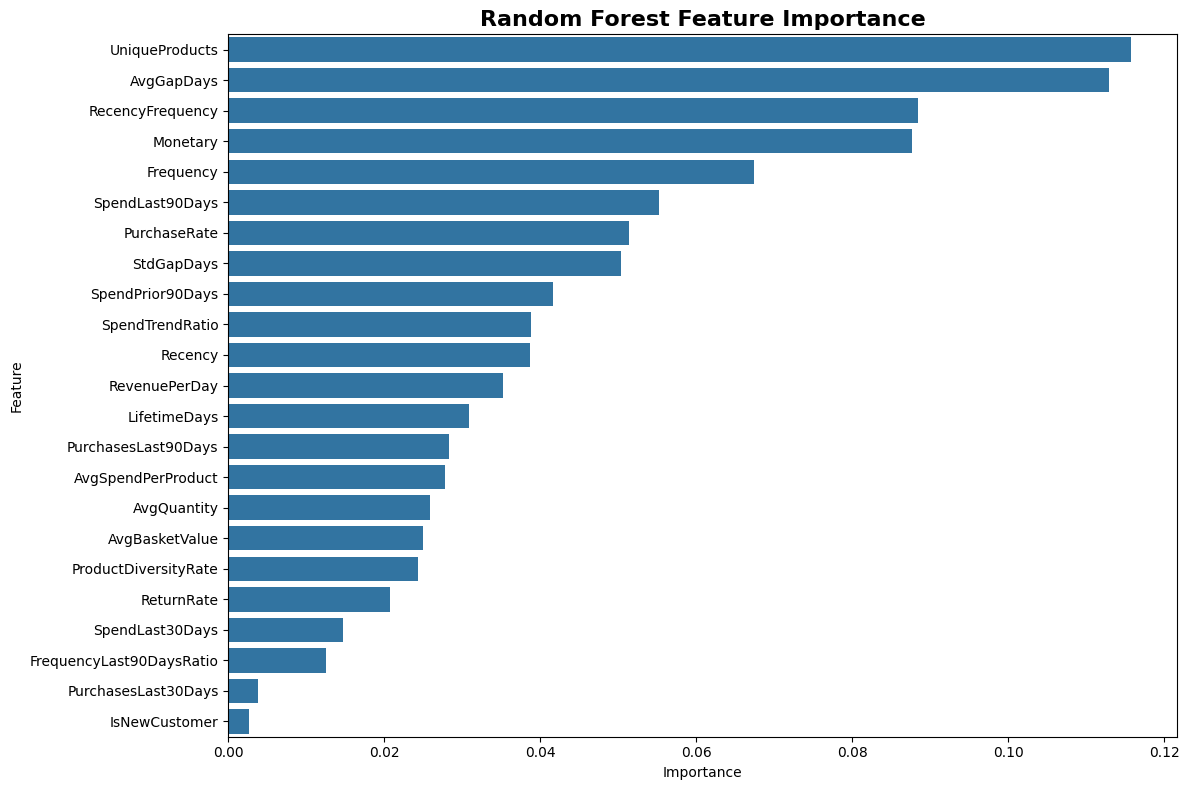

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = trained_models['RandomForest']

feature_names = (
    log_features +
    scale_features
)

importances = (
    rf_model
    .named_steps['model']
    .feature_importances_
)

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

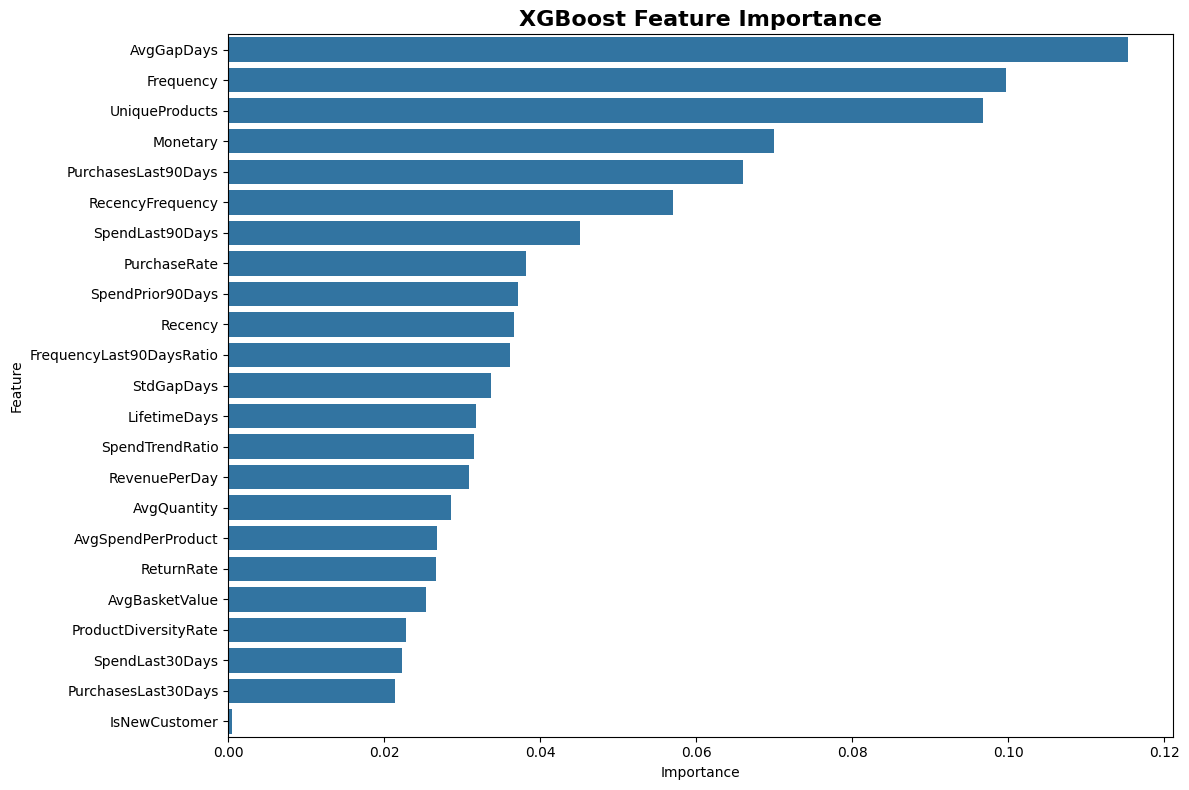

In [22]:
xgb_model = trained_models['XGBoost']

importances = (
    xgb_model
    .named_steps['model']
    .feature_importances_
)

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 0 Axes>

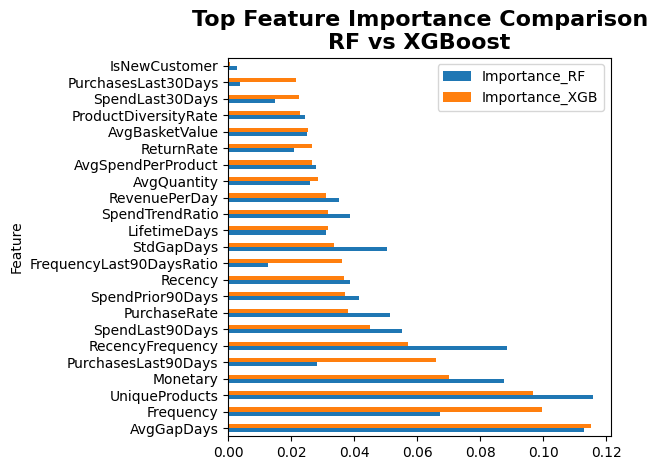

In [23]:
compare_df = pd.merge(
    rf_importance,
    xgb_importance,
    on="Feature",
    suffixes=("_RF", "_XGB")
)

compare_df = compare_df.sort_values(
    "Importance_XGB",
    ascending=False
)

plt.figure(figsize=(14,10))

compare_df.set_index("Feature")[
    ["Importance_RF","Importance_XGB"]
].plot(
    kind="barh"
)

plt.title(
    "Top Feature Importance Comparison\nRF vs XGBoost",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [24]:
print(xgb_importance.head(15))

                     Feature  Importance
14                AvgGapDays    0.115342
0                  Frequency    0.099677
3             UniqueProducts    0.096701
1                   Monetary    0.069985
17       PurchasesLast90Days    0.065927
20          RecencyFrequency    0.057054
5            SpendLast90Days    0.045077
13              PurchaseRate    0.038159
6           SpendPrior90Days    0.037162
11                   Recency    0.036659
22  FrequencyLast90DaysRatio    0.036053
15                StdGapDays    0.033709
12              LifetimeDays    0.031797
21           SpendTrendRatio    0.031526
7              RevenuePerDay    0.030897


In [26]:
import shap

# BEST MODEL
xgb_model = trained_models['XGBoost']

# EXTRACT TRAINED XGBOOST OBJECT
xgb_classifier = (
    xgb_model
    .named_steps['model']
)

# TRANSFORM TEST DATA
X_test_processed = (
    xgb_model
    .named_steps['preprocessing']
    .transform(X_test)
)

# SHAP EXPLAINER
explainer = shap.TreeExplainer(
    xgb_classifier
)

# SHAP VALUES
shap_values = explainer.shap_values(
    X_test_processed
)

In [27]:
feature_names = (
    log_features +
    scale_features
)

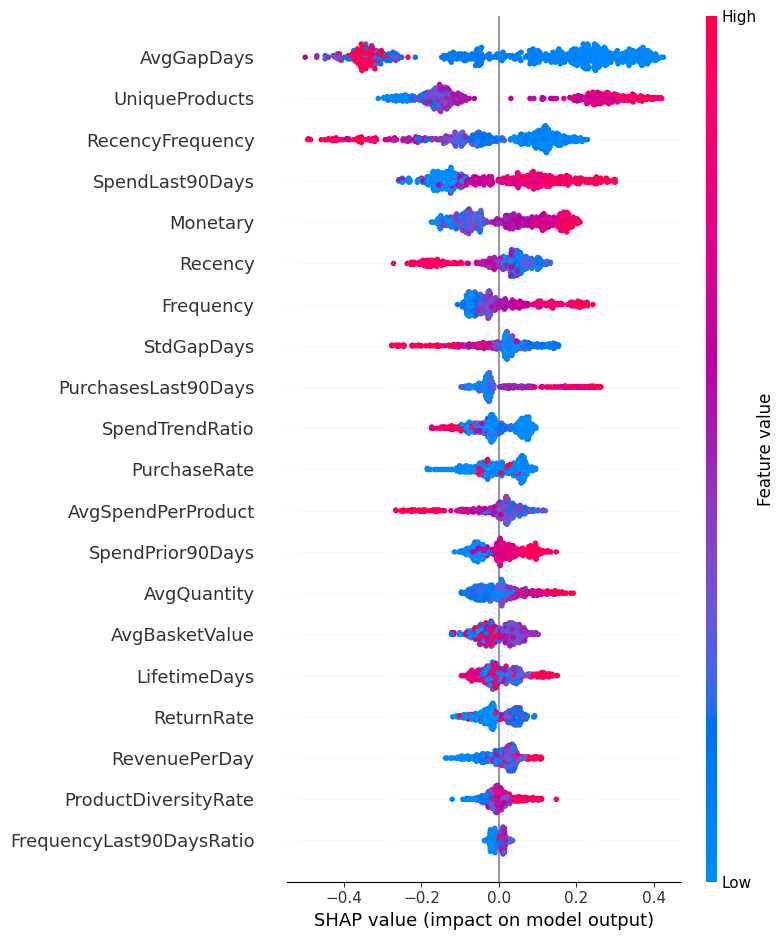

In [28]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

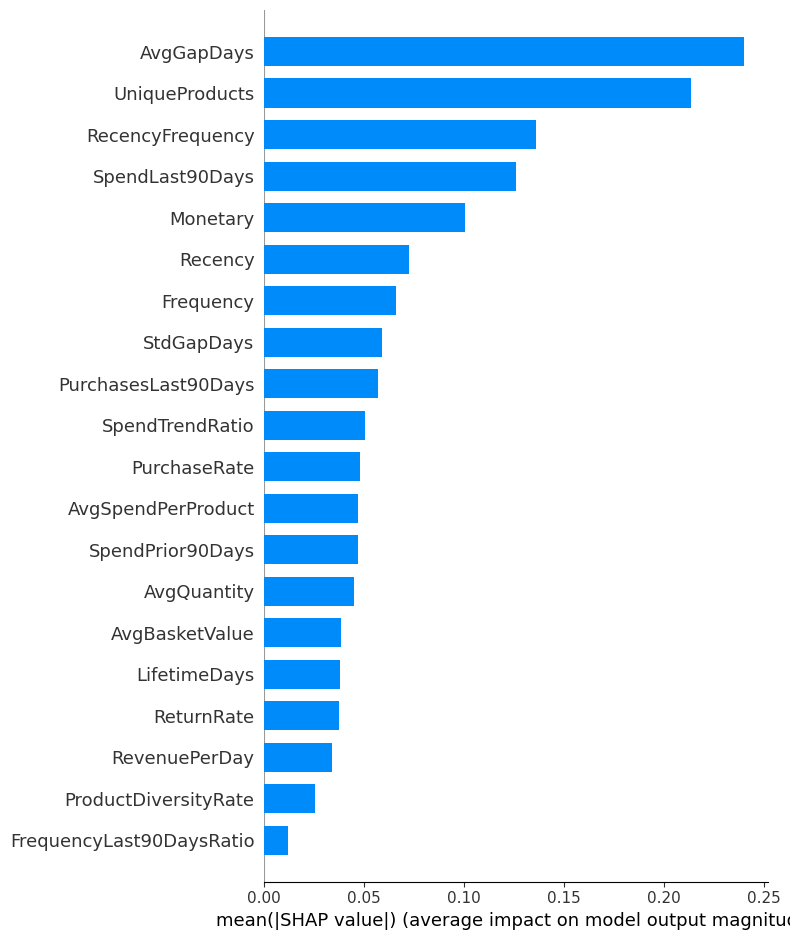

In [29]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

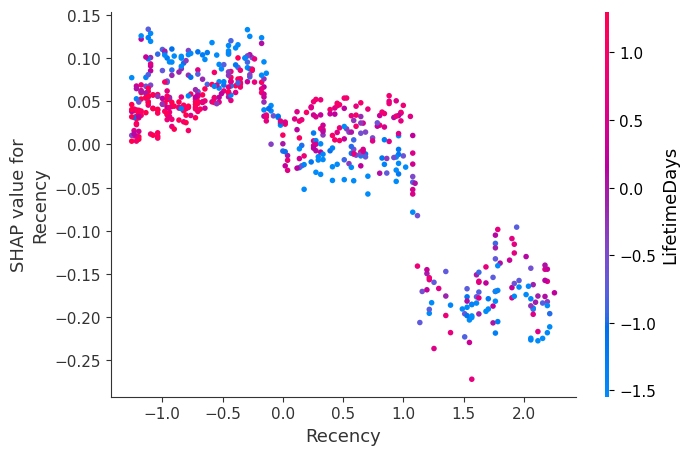

In [30]:
shap.dependence_plot(
    "Recency",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

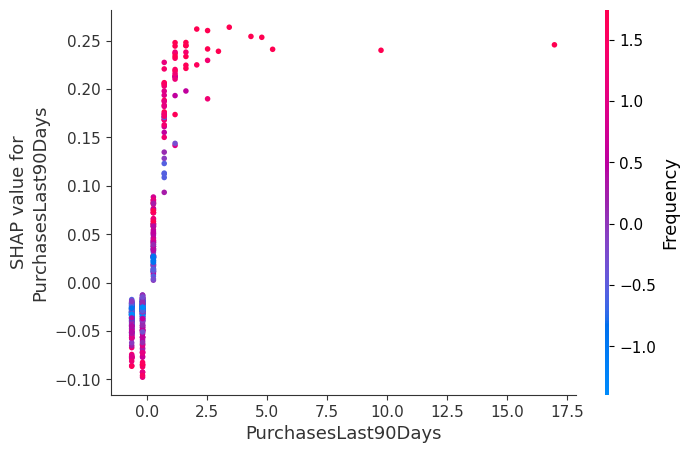

In [31]:
shap.dependence_plot(
    "PurchasesLast90Days",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

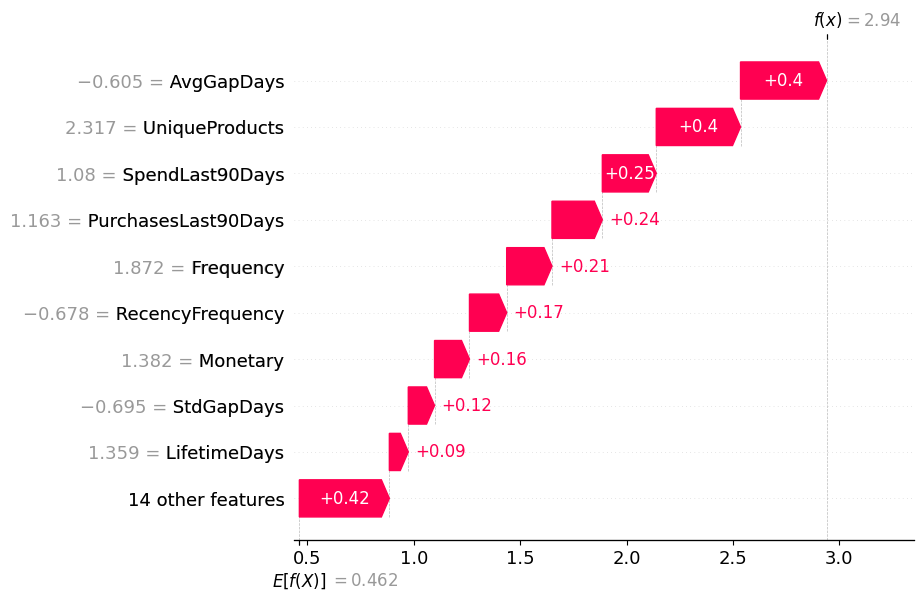

In [32]:
customer_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test_processed[customer_idx],
        feature_names=feature_names
    )
)

In [33]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
)

print(
    shap_importance.head(20)
)

                     Feature  MeanAbsSHAP
14                AvgGapDays     0.240089
3             UniqueProducts     0.213341
20          RecencyFrequency     0.135836
5            SpendLast90Days     0.125855
1                   Monetary     0.100321
11                   Recency     0.072483
0                  Frequency     0.065692
15                StdGapDays     0.058684
17       PurchasesLast90Days     0.056622
21           SpendTrendRatio     0.050250
13              PurchaseRate     0.047984
8         AvgSpendPerProduct     0.046898
6           SpendPrior90Days     0.046715
10               AvgQuantity     0.044912
2             AvgBasketValue     0.038337
12              LifetimeDays     0.037678
18                ReturnRate     0.037167
7              RevenuePerDay     0.033683
9       ProductDiversityRate     0.025441
22  FrequencyLast90DaysRatio     0.011942


In [52]:
# clv_regression.py

import pandas as pd
import numpy as np
 
# MAIN FUNCTION FOR BUILDING RETENTION CLASSIFICATION DATASET
def build_clv_dataset(df, cutoff_date='2011-09-09', prediction_days=90, active_days=180, verbose=True):

    # CONVERTING INPUT CUTOFF DATE INTO PANDAS TIMESTAMP
    # This becomes the boundary separating historical feature generation and Future retention label generation
    cutoff_date = pd.Timestamp(cutoff_date)

  
    # DEFINING FUTURE PREDICTION WINDOW END DATE
    # Customers purchasing between:
    # cutoff_date -> prediction_end
    # receive retention label = 1
    prediction_end = (cutoff_date + pd.Timedelta(days=prediction_days))

  
    # DEFINING RECENT ACTIVITY WINDOW
    # Customers inactive for too long before cutoff
    # are excluded to avoid trivial dead-user predictions
    active_start = (cutoff_date - pd.Timedelta(days=active_days))

  
    # FILTERING ONLY GENUINE PURCHASE TRANSACTIONS
    # Removing:
    # 1. Cancelled invoices
    # 2. Product returns
    # 3. Operational/non-product transactions
    purchase_df = df[
        (~df['IsCancelled']) &
        (~df['IsReturn']) &
        (~df['IsNonProduct'])].copy()

  
    # SORTING PURCHASES CHRONOLOGICALLY 
    # Sorting by customer then time is essential for:
    # 1. Gap calculations
    # 2. Recency features
    # 3. Temporal behavior modeling
    purchase_df = purchase_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # SPLITTING HISTORICAL AND FUTURE DATA
    # Historical data:
    # Used ONLY for feature engineering
    history_df = purchase_df[purchase_df['InvoiceDate'] < cutoff_date].copy()
    # Future data:
    # Used ONLY for retention label creation
    future_df = purchase_df[
        (purchase_df['InvoiceDate'] >= cutoff_date) &
        (purchase_df['InvoiceDate'] < prediction_end)
    ].copy()

  
    # IDENTIFYING RECENTLY ACTIVE CUSTOMERS
    # Keeping only customers active within recent window
    # avoids learning from ancient dormant customers
    recent_active_customers = (
        history_df[
            history_df['InvoiceDate'] >= active_start
        ]['Customer_ID']
        .unique()
    )

  
    # FILTERING HISTORY TO ACTIVE CUSTOMERS ONLY
    # This ensures:
    # every customer had at least some recent activity
    history_df = history_df[history_df['Customer_ID'].isin(recent_active_customers)]

  
    # FILTERING FUTURE DATA TO SAME CUSTOMER SET
    # Future labels must only exist for valid customers
    future_df = future_df[future_df['Customer_ID'].isin(recent_active_customers)]

  
    # CREATING INVOICE-LEVEL AGGREGATION
    # Raw dataset is transaction-line level:
    # one row per purchased item

    # Here we aggregate into one row per invoice/order
    # This captures cleaner order-level behavior
    invoice_df = (
        history_df
        .groupby(['Customer_ID', 'Invoice'])
        .agg({
            # First timestamp of invoice
            'InvoiceDate': 'min',
            # Total spend within invoice
            'TransactionValue': 'sum',
            # Total quantity purchased in invoice
            'Quantity': 'sum',
            # Number of unique products in invoice
            'StockCode': 'nunique'
        })
        .reset_index()
    )

  
    # SORTING INVOICE-LEVEL DATA CHRONOLOGICALLY
    # Required for temporal customer calculations
    invoice_df = invoice_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # CREATING CUSTOMER-LEVEL AGGREGATED FEATURES
    # Final dataset requires none row per customer
    # So invoice-level behavior is aggregated upward
    customer_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            # Most recent purchase timestamp
            LastPurchaseDate=('InvoiceDate', 'max'),
            # First ever purchase timestamp
            FirstPurchaseDate=('InvoiceDate', 'min'),
            # Total number of orders placed
            Frequency=('Invoice', 'nunique'),
            # Total customer spending
            Monetary=('TransactionValue', 'sum'),
            # Average spend per order
            AvgBasketValue=('TransactionValue', 'mean'),
            # Average quantity purchased per order
            AvgQuantity=('Quantity', 'mean'),
            # Total unique products purchased
            UniqueProducts=('StockCode', 'sum')
        )
        .reset_index()
    )

  
    # DERIVING RECENCY FEATURE
    # Measures: days since customer's last purchase
    # Lower recency usually means:
    # higher probability of returning
    customer_features['Recency'] = (cutoff_date - customer_features['LastPurchaseDate']).dt.days

  
    # DERIVING CUSTOMER LIFETIME FEATURE
    # Measures: duration between first and latest purchase
    # Helps distinguish new customers vs mature loyal customers
    customer_features['LifetimeDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days

  
    # PREVENTING DIVISION BY ZERO
    # Customers with single-day activity
    # would otherwise create divide-by-zero errors
    customer_features['LifetimeDays'] = (customer_features['LifetimeDays'].replace(0, 1))

    # FLAGGING RECENTLY ACQUIRED CUSTOMERS
    # New customers often behave differently from mature customers
    customer_features['IsNewCustomer'] = (
        customer_features['LifetimeDays'] <= 60
    ).astype(int)
  
    # DERIVING PURCHASE VELOCITY FEATURE
    # Measures: average order frequency per lifetime day
    # Captures long-term customer engagement intensity
    customer_features['PurchaseRate'] = (customer_features['Frequency']/customer_features['LifetimeDays'])

    # DERIVING RECENCY-FREQUENCY INTERACTION
    # Combines freshness and loyalty into one signal
    customer_features['RecencyFrequency'] = (customer_features['Recency'] / customer_features['Frequency'])

    # DERIVING REVENUE INTENSITY FEATURE
    # Measures average spending generated per day
    customer_features['RevenuePerDay'] = (
        customer_features['Monetary'] /
        customer_features['LifetimeDays']
    )

    # DERIVING PRODUCT SPEND INTENSITY FEATURE
    # Measures average spend per unique product purchased
    customer_features['AvgSpendPerProduct'] = (
        customer_features['Monetary'] /
        customer_features['UniqueProducts']
    )

    # DERIVING PRODUCT DIVERSITY FEATURE
    # Measures product variety purchased per order
    customer_features['ProductDiversityRate'] = (
        customer_features['UniqueProducts'] /
        customer_features['Frequency']
    )

    # CREATING PREVIOUS PURCHASE TIMESTAMPS
    # Previous invoice timestamps are needed
    # for inter-purchase gap calculations
    invoice_df['PrevInvoiceDate'] = (invoice_df.groupby('Customer_ID')['InvoiceDate'].shift(1))

  
    # CALCULATING INTER-PURCHASE GAPS
    # Measures: time gap between consecutive purchases
    # Highly informative behavioral feature
    invoice_df['GapDays'] = (invoice_df['InvoiceDate']-invoice_df['PrevInvoiceDate']).dt.days

  
    # DERIVING AVERAGE INTER-PURCHASE GAP
    # Customers with lower average gaps
    # often show stronger retention tendencies
    # DERIVING INTER-PURCHASE GAP STATISTICS
    gap_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            AvgGapDays=('GapDays', 'mean'),
            StdGapDays=('GapDays', 'std')
        )
        .reset_index()
    )


    # MERGING GAP FEATURES
    customer_features = customer_features.merge(
        gap_features,
        on='Customer_ID',
        how='left'
    )


    # SINGLE-PURCHASE CUSTOMERS HAVE NO GAP VARIANCE
    customer_features['StdGapDays'] = (
        customer_features['StdGapDays']
        .fillna(0)
    )


  
    # DEFINING RECENT 30-DAY ACTIVITY WINDOW
    # Recent activity often predicts
    # short-term retention strongly
    last_30_start = (cutoff_date - pd.Timedelta(days=30))

  
    # EXTRACTING RECENT CUSTOMER ACTIVITY
    # Captures customer momentum immediately
    # before prediction cutoff
    last_30_df = history_df[history_df['InvoiceDate'] >= last_30_start]

  
    # CREATING RECENT MOMENTUM FEATURES
    # These features capture:
    # recent engagement intensity
    recent_features = (
        last_30_df
        .groupby('Customer_ID')
        .agg(
            # Number of recent orders
            PurchasesLast30Days=('Invoice', 'nunique'),
            # Recent spending volume
            SpendLast30Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

  
    # MERGING RECENT MOMENTUM FEATURES
    customer_features = customer_features.merge(recent_features, on='Customer_ID', how='left')

  
    # FILLING MISSING RECENT ACTIVITY VALUES
    # Customers without recent purchases
    # should receive zeros instead of NaNs
    customer_features[['PurchasesLast30Days', 'SpendLast30Days']] = customer_features[['PurchasesLast30Days', 'SpendLast30Days']].fillna(0)



    # NEW
    # DEFINING RECENT 90-DAY ACTIVITY WINDOW
    # Captures medium-term customer engagement before cutoff
    last_90_start = (
        cutoff_date -
        pd.Timedelta(days=90)
    )


    # EXTRACTING LAST 90-DAY CUSTOMER ACTIVITY
    last_90_df = history_df[
        history_df['InvoiceDate'] >= last_90_start
    ]

    # CREATING MEDIUM-TERM MOMENTUM FEATURES
    recent_90_features = (
        last_90_df
        .groupby('Customer_ID')
        .agg(
            PurchasesLast90Days=('Invoice', 'nunique'),
            SpendLast90Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

    # MERGING MEDIUM-TERM MOMENTUM FEATURES
    customer_features = customer_features.merge(
        recent_90_features,
        on='Customer_ID',
        how='left'
    )

    # FILLING MISSING VALUES
    customer_features[
        ['PurchasesLast90Days', 'SpendLast90Days']
    ] = customer_features[
        ['PurchasesLast90Days', 'SpendLast90Days']
    ].fillna(0)



    # DEFINING PRIOR 90-DAY WINDOW
    # Window from cutoff-180 to cutoff-90
    prior_90_start = (
        cutoff_date -
        pd.Timedelta(days=180)
    )

    prior_90_end = (
        cutoff_date -
        pd.Timedelta(days=90)
    )

    # EXTRACTING PRIOR WINDOW ACTIVITY
    prior_90_df = history_df[
        (history_df['InvoiceDate'] >= prior_90_start) &
        (history_df['InvoiceDate'] < prior_90_end)
    ]

    # CALCULATING PRIOR WINDOW ACTIVITY
    prior_90_features = (
        prior_90_df
        .groupby('Customer_ID')
        .agg(
            SpendPrior90Days=('TransactionValue', 'sum'),
            PurchasesPrior90Days=('Invoice', 'nunique')
        )
        .reset_index()
    )

    # MERGING PRIOR WINDOW FEATURES
    customer_features = customer_features.merge(
        prior_90_features,
        on='Customer_ID',
        how='left'
    )

    customer_features[
        ['SpendPrior90Days','PurchasesPrior90Days']
    ] = customer_features[
        ['SpendPrior90Days','PurchasesPrior90Days']
    ].fillna(0)



    # DERIVING SPENDING MOMENTUM FEATURE
    # Ratio > 1 means accelerating spend
    # Ratio < 1 means declining spend
    customer_features['SpendTrendRatio'] = (
        customer_features['SpendLast90Days'] /
        (
            customer_features['SpendPrior90Days']
            + 1
        )
    )


    # DERIVING PURCHASE MOMENTUM FEATURE
    # Ratio > 1 means increasing purchase frequency
    # Ratio < 1 means declining purchase frequency
    customer_features['FrequencyLast90DaysRatio'] = (
        customer_features['PurchasesLast90Days'] /
        (
            customer_features['PurchasesPrior90Days']
            + 1
        )
    )


    # COLLECTING HISTORICAL RETURN/CANCELLATION DATA
    # Behavioral instability signals
    # may help predict retention
    cancellation_df = df[(df['InvoiceDate'] < cutoff_date)]

  
    # CREATING RETURN/CANCELLATION FEATURES
    cancellation_features = (
        cancellation_df
        .groupby('Customer_ID')
        .agg(
            # Total historical transaction count
            TotalTransactions=('Invoice', 'count'),
            # Number of cancelled transactions
            CancelledTransactions=('IsCancelled', 'sum'),
            # Number of returned transactions
            ReturnedTransactions=('IsReturn', 'sum')
        ).reset_index())

  
    '''# DERIVING CANCELLATION RATE
    # Measures: proportion of customer cancellations
    cancellation_features['CancellationRate'] = (cancellation_features['CancelledTransactions']/cancellation_features['TotalTransactions'])
    '''
  
    # DERIVING RETURN RATE
    # Measures: proportion of customer returns
    # Found out that cancellation rate and return rate are same, correlation = 1.0
    cancellation_features['ReturnRate'] = (cancellation_features['ReturnedTransactions']/cancellation_features['TotalTransactions'])

  
    # MERGING CANCELLATION FEATURES
    customer_features = customer_features.merge(cancellation_features[
            [
                'Customer_ID',
                'ReturnRate'
            ]
        ],
        on='Customer_ID',
        how='left')

  
    # IDENTIFYING FUTURE RETURNING CUSTOMERS
    # Customers purchasing during future window
    # become positive retention examples
    future_labels = (
        future_df
        .groupby('Customer_ID')
        .agg(
            FutureSpend90Days=
            ('TransactionValue','sum')
        )
        .reset_index()
    )

  
    # MERGING LABELS INTO FINAL FEATURE TABLE
    customer_features = customer_features.merge(
        future_labels[
            ['Customer_ID', 'FutureSpend90Days']
        ],
        on='Customer_ID',
        how='left'
    )

  
    # FILLING MISSING FUTURE SPEND WITH 0
    # Customers with no future purchases
    # have 0 future spend
    customer_features['FutureSpend90Days'] = (
        customer_features['FutureSpend90Days']
        .fillna(0)
    )

  
    # REMOVING RAW TIMESTAMP COLUMNS
    # Derived features already contain needed information
    customer_features = customer_features.drop(columns=['LastPurchaseDate','FirstPurchaseDate'])

  
    # PRINTING FINAL DATASET STATISTICS
    if verbose:

        print(f"Cutoff date: {cutoff_date.date()}")

        print(f"Prediction end: {prediction_end.date()}")

        print(f"Active customer window: {active_days} days")

        print(f"Final dataset shape: {customer_features.shape}")

        print(f"Customers avg spend in the 90 days after cutoff: ", f"{customer_features['FutureSpend90Days'].mean():.2f}")

        print(f"Number of customers who had a spending > 0 in the 90 days after cutoff: ", f"{customer_features['FutureSpend90Days'].value_counts().sum()}")

        print(f"Number of customers who had no spending in the 90 days after cutoff: ", f"{(customer_features['FutureSpend90Days'] == 0).sum()}")

    return customer_features


 
# TEST EXECUTION
 

if __name__ == "__main__":

    # Importing preprocessing pipeline
    from preprocessing import preprocess_online_retail

    # Loading cleaned master transaction dataset
    df = preprocess_online_retail(
        file_path="online_retail_II.xlsx",
        verbose=False
    )

    # Building customer-level retention dataset
    clv_df = build_clv_dataset(
        df,
        cutoff_date='2011-09-09',
        prediction_days=90,
        active_days=180,
        verbose=True
    )

    # Printing sample rows from final dataset
    print(clv_df.head())

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071
  Customer_ID  Frequency  Monetary  AvgBasketValue  AvgQuantity  \
0       12347          6   3402.39      567.065000   349.833333   
1       12348          4   1388.40      347.100000   622.000000   
2       12352          7   1825.61      260.801429    62.857143   
3       12353          2    406.76      203.380000   106.000000   
4       12354          1   1079.40     1079.400000   530.000000   

   UniqueProducts  Recency  LifetimeDays  IsNewCustomer  PurchaseRate  ...  \
0             164       37           274              0      0.021898  ...   
1              40      156           189              0      0.021164  ...   
2              52      170           

In [53]:
clv_df.head()

,Customer_ID,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,IsNewCustomer,PurchaseRate,...,PurchasesLast30Days,SpendLast30Days,PurchasesLast90Days,SpendLast90Days,SpendPrior90Days,PurchasesPrior90Days,SpendTrendRatio,FrequencyLast90DaysRatio,ReturnRate,FutureSpend90Days
0,12347,6,3402.39,567.065000,349.833333,164,37,274,0,0.021898,...,0.0,0.0,1.0,584.91,1018.77,2.0,0.573571,0.333333,0.000000,1519.14
1,12348,4,1388.40,347.100000,622.000000,40,156,189,0,0.021164,...,0.0,0.0,0.0,0.00,327.00,1.0,0.000000,0.000000,0.000000,270.00
2,12352,7,1825.61,260.801429,62.857143,52,170,130,0,0.053846,...,0.0,0.0,0.0,0.00,240.66,2.0,0.000000,0.000000,0.151515,744.23
3,12353,2,406.76,203.380000,106.000000,24,112,204,0,0.009804,...,0.0,0.0,0.0,0.00,89.00,1.0,0.000000,0.000000,0.000000,0.00
4,12354,1,1079.40,1079.400000,530.000000,58,140,1,1,1.000000,...,0.0,0.0,0.0,0.00,1079.40,1.0,0.000000,0.000000,0.000000,0.00


In [ ]:
clv_df.describe()

,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,IsNewCustomer,PurchaseRate,RecencyFrequency,...,PurchasesLast30Days,SpendLast30Days,PurchasesLast90Days,SpendLast90Days,SpendPrior90Days,PurchasesPrior90Days,SpendTrendRatio,FrequencyLast90DaysRatio,ReturnRate,RetentionLabel
count,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,...,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000
mean,8.552556,4114.153446,390.328561,238.229856,173.963283,65.051116,337.581713,0.194744,0.181019,25.431398,...,0.476242,225.863247,1.403528,652.512758,637.654748,1.464003,144.869670,0.675533,0.025270,0.614471
std,14.639871,16433.334077,539.056194,380.385311,365.083968,51.403691,218.839638,0.396075,0.376934,36.644876,...,0.939842,1068.208909,2.255122,2641.294116,2228.747639,2.252107,398.539222,0.728706,0.051574,0.486808
min,1.000000,2.900000,2.900000,1.000000,1.000000,0.000000,1.000000,0.000000,0.003165,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,586.532500,194.932917,101.638249,33.000000,20.000000,123.000000,0.000000,0.012870,2.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,1464.725000,301.698000,170.888889,84.000000,52.000000,387.500000,0.000000,0.021613,11.250000,...,0.000000,0.000000,1.000000,229.655000,277.355000,1.000000,0.875056,0.500000,0.004878,1.000000
75%,10.000000,3494.707500,435.649063,276.500000,199.000000,104.000000,528.000000,0.000000,0.047968,31.000000,...,1.000000,212.470000,2.000000,600.075000,610.665000,2.000000,118.767500,1.000000,0.030512,1.000000
max,308.000000,456780.490000,14844.766667,12669.142857,8982.000000,179.000000,646.000000,1.000000,3.000000,179.000000,...,16.000000,29775.780000,46.000000,62151.700000,57876.900000,43.000000,5551.510000,6.000000,0.666667,1.000000


In [56]:
print(
    clv_df['FutureSpend90Days']
    .quantile([0.25,0.5,0.75,0.9,0.95,0.99])
)

0.25        0.0000
0.50      246.5600
0.75      790.9150
0.90     1674.7700
0.95     2711.6185
0.99    10469.6179
Name: FutureSpend90Days, dtype: float64


In [55]:
print(
    clv_df['FutureSpend90Days']
    .skew()
)

18.942058470232723


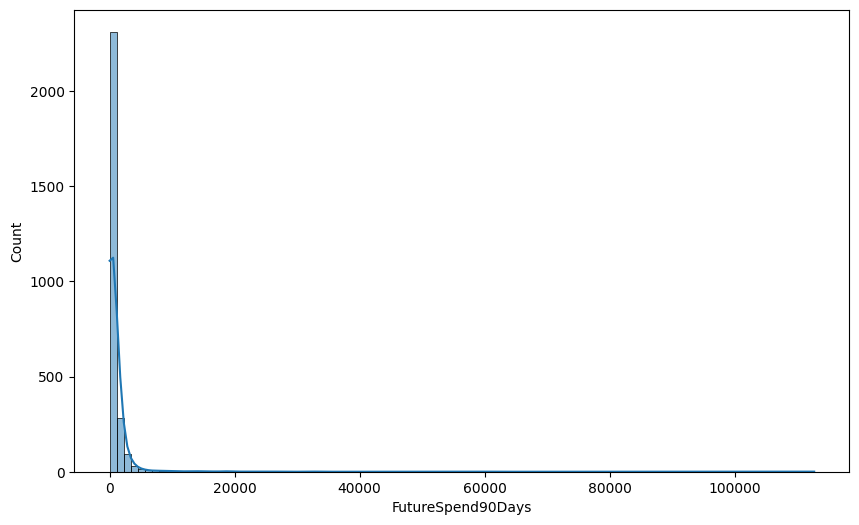

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(
    clv_df['FutureSpend90Days'],
    bins=100,
    kde=True
)

plt.show()

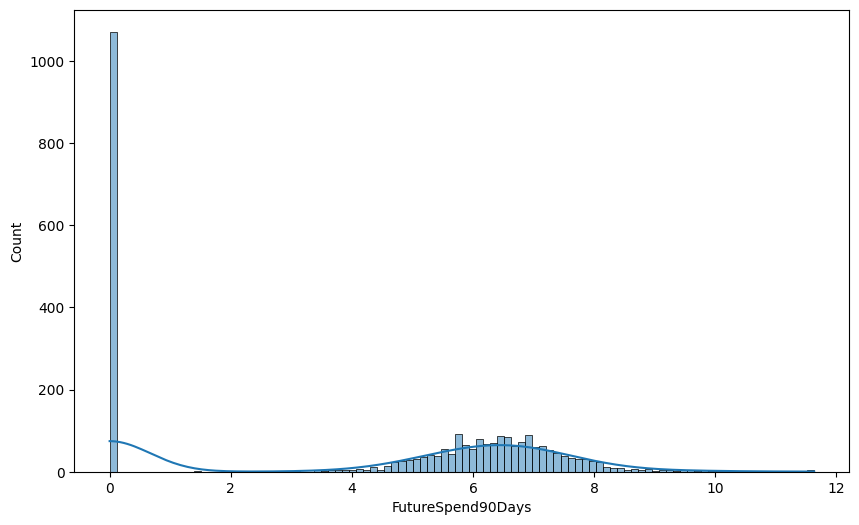

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(clv_df['FutureSpend90Days']),
    bins=100,
    kde=True
)

plt.show()

In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (train_test_split, RandomizedSearchCV)

# Preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler


# Missing value handling
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# XGBoost regressor
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)

# Dataset creation pipeline
from classf_dataset import build_retention_dataset


# Preprocessing pipeline
from preprocessing import preprocess_online_retail


# LOADING CLEANED MASTER DATASET
   
df = preprocess_online_retail(file_path="online_retail_II.xlsx", verbose=False)

# BUILDING CUSTOMER RETENTION DATASET
   
retention_df = build_clv_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)


# HANDLING AvgGapDays MISSING VALUES
# Customers with one purchase have no gap history
retention_df['AvgGapDays'] = (retention_df['AvgGapDays'].fillna(999))

# SPLITTING FEATURES AND TARGET
# Input features
X = retention_df.drop(columns=['Customer_ID', 'FutureSpend90Days'])

# Target labels
y = np.log1p(retention_df['FutureSpend90Days'])

# TRAIN TEST SPLIT
# Stratify preserves class distribution balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# FEATURES NEEDING LOG TRANSFORMATION  
# Highly right-skewed behavioral features
log_features = ['Frequency', 'Monetary', 'AvgBasketValue', 'UniqueProducts', 'SpendLast30Days', 'SpendLast90Days', 'SpendPrior90Days', 'RevenuePerDay', 'AvgSpendPerProduct', 'ProductDiversityRate']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency', 'LifetimeDays', 'PurchaseRate','AvgGapDays','StdGapDays','PurchasesLast30Days','PurchasesLast90Days','ReturnRate', 'IsNewCustomer','RecencyFrequency','SpendTrendRatio','FrequencyLast90DaysRatio']

# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Applying log(1+x)
    ('log_transform', FunctionTransformer(np.log1p)),
    # Standardizing transformed values
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Standard scaling
    ('scaler', StandardScaler())])


# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)],
    remainder='drop')


# DEFINING MODELS   
models = {'Ridge_linearreg': Ridge(),
          'KNN': KNeighborsRegressor(),
          'DecisionTree': DecisionTreeRegressor(random_state=42),    
          'SVR': SVR(), 
          'RandomForest': RandomForestRegressor(random_state=42),
          'XGBoost': XGBRegressor(objective='reg:squarederror', eval_metric='rmse',random_state=42),
          'ExtraTrees':ExtraTreesRegressor(random_state=42),
          'HistGBM':HistGradientBoostingRegressor(random_state=42),
          'LGBM': LGBMRegressor(objective='regression',random_state=42,verbose=-1),
          'CatBoost': CatBoostRegressor(loss_function='RMSE',random_seed=42,verbose=0)
          }
#scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())
   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'Ridge_linearreg': {'model__alpha':[0.001,0.01,0.1,1,10,100]},
    'KNN': {'model__n_neighbors': [3, 5, 7, 11, 15, 20, 25, 30], 'model__weights': ['uniform', 'distance'], 'model__p': [1, 2]},
    'DecisionTree': {'model__max_depth':[3,5,10,15,20,30,None],'model__min_samples_split':[2,5,10,20,50],'model__min_samples_leaf':[1,2,4,8,16]},
    'SVR': {'model__kernel':['rbf','linear'],'model__C':[0.1,1,5,10,20,50,100],'model__gamma':['scale',0.001,0.01,0.05,0.1,0.5],'model__epsilon':[0.01,0.05,0.1,0.2]},
    'RandomForest': {'model__n_estimators':[100,200,500,1000], 'model__max_depth':[3,5,10,20,None], 'model__min_samples_split':[2,5,10,20,30,50], 'model__min_samples_leaf':[1,2,4,8,12,18], 'model__max_features':['sqrt','log2']},
    'XGBoost': {'model__n_estimators':[100,200,500,1000], 'model__max_depth':[3,4,5,6,8], 'model__learning_rate':[0.01,0.03,0.05,0.1], 'model__subsample':[0.6,0.8,1.0], 'model__colsample_bytree':[0.6,0.8,1.0], 'model__min_child_weight':[1,3,5,7], 'model__gamma':[0,0.1,0.3,0.5], 'model__reg_alpha':[0,0.01,0.1], 'model__reg_lambda':[1,2,5]},
    'ExtraTrees': {'model__n_estimators':[200,500,1000], 'model__max_depth':[5,10,20,None], 'model__min_samples_split':[2,5,10], 'model__min_samples_leaf':[1,2,4,8]},
    'HistGBM':{'model__learning_rate':[0.01,0.03,0.05,0.1], 'model__max_depth':[3,5,8,None], 'model__max_iter':[100,300,500,1000],'model__min_samples_leaf':[10,20,50],'model__l2_regularization':[0,0.01,0.1,1]},
    'LGBM': {'model__n_estimators': [100, 200, 500, 1000],'model__learning_rate': [0.01,0.03,0.05,0.1],'model__max_depth': [3,5,7,10,-1],'model__num_leaves': [15,31,63,127],'model__subsample': [0.6,0.8,1.0],'model__colsample_bytree': [0.6,0.8,1.0],'model__min_child_samples': [5,10,20,50],'model__reg_alpha': [0,0.01,0.1,1],'model__reg_lambda': [0,0.01,0.1,1,5]},
    'CatBoost': {'model__iterations':[100,200,500,1000],'model__learning_rate':[0.01,0.03,0.05,0.1],'model__depth':[3,4,5,6,8,10],'model__l2_leaf_reg':[1,3,5,7,10],'model__border_count':[32,64,128,255],'model__subsample':[0.6,0.8,1.0],'model__colsample_bylevel':[0.6,0.8,1.0],'model__random_strength':[0,0.1,0.3,0.5,1.0],'model__l2_leaf_reg':[1,3,5,7,10],'model__border_count':[32,64,128,255],'model__random_strength':[0,0.1,0.3,0.5,1.0]}}
    


baseline_pred = np.repeat(
    np.expm1(y_train).mean(),
    len(y_test)
)

baseline_rmse = root_mean_squared_error(
    np.expm1(y_test),
    baseline_pred
)

print("Baseline RMSE:",
      baseline_rmse)

# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # CREATING COMPLETE MODEL PIPELINE
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    # RANDOMIZED HYPERPARAMETER SEARCH
    random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_grids[model_name],
        n_iter=120, cv=5, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)

    # TRAINING MODEL
    random_search.fit(X_train, y_train)

    # BEST MODEL AFTER SEARCH
    best_model = random_search.best_estimator_
    trained_models[model_name] = best_model

    # PREDICTING TEST LABELS
    y_pred = best_model.predict(X_test)

    # APPLYING EXPONENTIAL TRANSFORMATION BACK FROM LOG SCALE
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(best_model.predict(X_test))


    # CALCULATING EVALUATION METRICS
    MSE = mean_squared_error(y_test_actual, y_pred_actual)

    RMSE = root_mean_squared_error(y_test_actual, y_pred_actual)

    MAE = mean_absolute_error(y_test_actual, y_pred_actual)

    R2 = r2_score(y_test_actual, y_pred_actual)

    MEDIAN_AE = median_absolute_error(y_test_actual, y_pred_actual)

    RMSE_LOG = root_mean_squared_error(y_test, y_pred)

    R2_LOG = r2_score(y_test, y_pred)

       # PRINTING MODEL PERFORMANCE
   
    print(f"Best Params: {random_search.best_params_}")

    print(f"MSE: {MSE:.4f}")

    print(f"RMSE: {RMSE:.4f}")

    print(f"MAE: {MAE:.4f}")

    print(f"R2: {R2:.4f}")

    print(f"MEDIAN_AE: {MEDIAN_AE:.4f}")

    print(f"RMSE_LOG: {RMSE_LOG:.4f}")

    print(f"R2_LOG: {R2_LOG:.4f}")


    # STORING RESULTS
   
    results.append({'Model': model_name, 'MSE': MSE, 'RMSE': RMSE,
        'MAE': MAE, 'R2': R2, 'MEDIAN_AE': MEDIAN_AE, 'RMSE_LOG': RMSE_LOG, 'R2_LOG': R2_LOG})

   # FINAL MODEL COMPARISON TABLE
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='RMSE_LOG', ascending=True)


# PRINTING FINAL RESULTS   
print("\nFinal Model Comparison:\n")
print(results_df)

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071
Baseline RMSE: 4952.48283156007

Training Ridge_linearreg...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=120. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__alpha': 10}
MSE: 11952042.0689
RMSE: 3457.1726
MAE: 649.6397
R2: 0.5127
MEDIAN_AE: 226.8044
RMSE_LOG: 2.7018
R2_LOG: 0.2802

Training KNN...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=120. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__weights': 'uniform', 'model__p': 1, 'model__n_neighbors': 30}
MSE: 22032822.5363
RMSE: 4693.9133
MAE: 717.4327
R2: 0.1017
MEDIAN_AE: 228.2534
RMSE_LOG: 2.7198
R2_LOG: 0.2706

Training DecisionTree...
Best Params: {'model__min_samples_split': 50, 'model__min_samples_leaf': 16, 'model__max_depth': 5}
MSE: 20146146.9440
RMSE: 4488.4459
MAE: 724.1284
R2: 0.1786
MEDIAN_AE: 230.5314
RMSE_LOG: 2.8238
R2_LOG: 0.2138

Training SVR...
Best Params: {'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__epsilon': 0.1, 'model__C': 1}
MSE: 18660774.1724
RMSE: 4319.8118
MAE: 664.7561
R2: 0.2392
MEDIAN_AE: 232.3108
RMSE_LOG: 2.8590
R2_LOG: 0.1941

Training RandomForest...
Best Params: {'model__n_estimators': 200, 'model__min_samples_split': 50, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20}
MSE: 20327678.6674
RMSE: 4508.6227
MAE: 691.4670
R2: 0.1712
MEDIAN_AE: 213.5851
RMSE_LOG: 2.7117
R2_LOG: 0.2750

Training XGBoost...
Best Params: {'model_

e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Best Params: {'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 1, 'model__num_leaves': 15, 'model__n_estimators': 100, 'model__min_child_samples': 10, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
MSE: 19650453.1746
RMSE: 4432.8832
MAE: 684.5224
R2: 0.1988
MEDIAN_AE: 224.3124
RMSE_LOG: 2.7245
R2_LOG: 0.2681

Training CatBoost...


e:\Python\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
11 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
11 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Python\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "e:\Python\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~~~~~~~~~

Best Params: {'model__subsample': 0.6, 'model__random_strength': 0.3, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 7, 'model__iterations': 500, 'model__depth': 5, 'model__colsample_bylevel': 1.0, 'model__border_count': 255}
MSE: 20513664.1912
RMSE: 4529.2013
MAE: 694.3160
R2: 0.1636
MEDIAN_AE: 217.0895
RMSE_LOG: 2.7113
R2_LOG: 0.2752

Final Model Comparison:

             Model           MSE         RMSE         MAE        R2  \
0  Ridge_linearreg  1.195204e+07  3457.172554  649.639705  0.512700   
9         CatBoost  2.051366e+07  4529.201275  694.315996  0.163632   
4     RandomForest  2.032768e+07  4508.622702  691.467040  0.171215   
5          XGBoost  1.956531e+07  4423.269251  682.598565  0.202297   
1              KNN  2.203282e+07  4693.913350  717.432677  0.101694   
8             LGBM  1.965045e+07  4432.883167  684.522417  0.198826   
6       ExtraTrees  1.552988e+07  3940.797241  682.491911  0.366827   
7          HistGBM  2.114360e+07  4598.216796  688.745761  0.13

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    median_absolute_error
)
from clv_dataset import build_retention_dataset
from preprocessing import preprocess_online_retail

# LOADING CLEANED MASTER DATASET
df = preprocess_online_retail(file_path="online_retail_II.xlsx", verbose=False)

# BUILDING CUSTOMER clv DATASET
clv_df = build_retention_dataset(
    df,
    cutoff_date='2011-09-09',
    prediction_days=90,
    active_days=180,
    verbose=True
)

# HANDLING AvgGapDays MISSING VALUES
clv_df['AvgGapDays'] = clv_df['AvgGapDays'].fillna(999)

# SPLITTING FEATURES AND TARGET
X = clv_df.drop(columns=['Customer_ID', 'FutureSpend90Days'])

# Target labels (NO LOG TRANSFORM FOR TWEEDIE)
y = clv_df['FutureSpend90Days']

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# FEATURES NEEDING LOG TRANSFORMATION  
log_features = ['Frequency', 'Monetary', 'AvgBasketValue', 'UniqueProducts', 'SpendLast30Days', 'SpendLast90Days', 'SpendPrior90Days', 'RevenuePerDay', 'AvgSpendPerProduct', 'ProductDiversityRate']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency', 'LifetimeDays', 'PurchaseRate','AvgGapDays','StdGapDays','PurchasesLast30Days','PurchasesLast90Days','ReturnRate', 'IsNewCustomer','RecencyFrequency','SpendTrendRatio','FrequencyLast90DaysRatio']

# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)],
    remainder='drop')

# DEFINING MODELS WITH TWEEDIE OBJECTIVE
models = {
    'XGBoost_Tweedie': XGBRegressor(objective='reg:tweedie', eval_metric='tweedie-nloglik@1.5', tweedie_variance_power=1.5, tree_method='hist', random_state=42),     
    'LGBM_Tweedie': LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1)
}
   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'XGBoost_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__max_depth':[2,3,4,5],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_weight':[1,3,5,7],
        'model__reg_alpha':[0,0.01,0.1],
        'model__reg_lambda':[1,2,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    },
    'LGBM_Tweedie': {
        'model__n_estimators':[100,200,500,1000],
        'model__learning_rate':[0.01,0.03,0.05,0.1],
        'model__max_depth':[3,5,7,-1],
        'model__num_leaves':[15,31,63],
        'model__subsample':[0.6,0.8,1.0],
        'model__colsample_bytree':[0.6,0.8,1.0],
        'model__min_child_samples':[10,20,50],
        'model__reg_alpha':[0,0.01,0.1,1],
        'model__reg_lambda':[0.1,1,5,10],
        'model__tweedie_variance_power':[1.1,1.3,1.5,1.7,1.9]
    }
}

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
print("Baseline RMSE:", baseline_rmse)

# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    random_search = RandomizedSearchCV(
        estimator=pipeline, 
        param_distributions=param_grids[model_name],
        n_iter=100, 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    trained_models[model_name] = best_model

    y_pred = best_model.predict(X_test)
    
    # Tweedie models naturally predict >= 0, but enforce it just in case
    y_pred = np.maximum(0, y_pred)

    # CALCULATING EVALUATION METRICS ON ORIGINAL SCALE directly
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)
    MEDIAN_AE = median_absolute_error(y_test, y_pred)

    print(f"Best Params: {random_search.best_params_}")
    print(f"MSE: {MSE:.4f}")
    print(f"RMSE: {RMSE:.4f}")
    print(f"MAE: {MAE:.4f}")
    print(f"R2: {R2:.4f}")
    print(f"MEDIAN_AE: {MEDIAN_AE:.4f}")

    results.append({
        'Model': model_name, 
        'MSE': MSE, 
        'RMSE': RMSE,
        'MAE': MAE, 
        'R2': R2, 
        'MEDIAN_AE': MEDIAN_AE
    })

# FINAL MODEL COMPARISON TABLE
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='RMSE', ascending=True)

print("\nFinal Model Comparison:\n")
print(results_df)


Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 26)
Customers avg spend in the 90 days after cutoff:  899.50
Number of customers who had a spending > 0 in the 90 days after cutoff:  2778
Number of customers who had no spending in the 90 days after cutoff:  1071
Baseline RMSE: 4952.482831560069

Training XGBoost_Tweedie...
Best Params: {'model__tweedie_variance_power': 1.1, 'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
MSE: 6837399.7848
RMSE: 2614.8422
MAE: 598.7982
R2: 0.7212
MEDIAN_AE: 258.8526

Training LGBM_Tweedie...
Best Params: {'model__tweedie_variance_power': 1.1, 'model__subsample': 0.6, 'model__reg_lambda': 0.1, 'model__reg_alpha': 0.1, 'model__num_leaves': 31, 'model__n_estimators': 200, 'model__min_child_samples': 20, 'model__max_depth': 7, '

e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [62]:
results_df

,Model,MSE,RMSE,MAE,R2,MEDIAN_AE
0,XGBoost_Tweedie,6.837400e+06,2614.842210,598.798220,0.721231,258.85256
1,LGBM_Tweedie,8.321257e+06,2884.658887,603.967232,0.660732,242.67472


In [60]:
revenue_error_pct = (
    abs(y_test_actual.sum() - y_pred_actual.sum()) /
    y_test_actual.sum()
) * 100

print(f"Revenue Error %: {revenue_error_pct:.2f}")

Revenue Error %: 66.67


In [61]:
RMSLE = root_mean_squared_error(
    np.log1p(y_test_actual),
    np.log1p(y_pred_actual)
)

print(f"RMSLE: {RMSLE:.4f}")

RMSLE: 2.7113


In [63]:
actual_total = y_test_actual.sum()
predicted_total = y_pred_actual.sum()

print("Actual total revenue:", actual_total)
print("Predicted total revenue:", predicted_total)

print("Prediction / Actual ratio:", predicted_total / actual_total)

print("Actual mean:", y_test_actual.mean())
print("Predicted mean:", y_pred_actual.mean())

Actual total revenue: 498760.5
Predicted total revenue: 166238.4972092717
Prediction / Actual ratio: 0.33330325318318454
Actual mean: 897.0512589928057
Predicted mean: 298.9901028943736


In [68]:
calibration_factor = y_train.sum() / y_pred_actual.sum()
calibration_factor/4

np.float64(3.0077858672564606)

In [70]:
y_pred_actual_calibrated = y_pred_actual * calibration_factor

y_train_pred_actual = best_model.predict(X_train)
y_train_pred_actual = np.maximum(y_train_pred_actual, 0)

calibration_factor = np.expm1(y_train).sum() / y_train_pred_actual.sum()

y_pred_actual_calibrated = y_pred_actual * calibration_factor

e:\Python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\Python\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
revenue_error_pct = (
    abs(y_test_actual.sum() - y_pred_actual_calibrated.sum()) /
    y_test_actual.sum()
) * 100

RMSE = root_mean_squared_error(
    y_test_actual,
    y_pred_actual_calibrated
)

MAE = mean_absolute_error(
    y_test_actual,
    y_pred_actual_calibrated
)

R2 = r2_score(
    y_test_actual,
    y_pred_actual_calibrated
)